In [1]:
# ---- SETUP -----
# Libraries
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DateFormatter
from matplotlib.ticker import MaxNLocator
import scipy.signal as sg
# Logging configuration
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Data retrieving function
def retrieve_data(file_path:str) -> tuple[list[pd.Timestamp], list[float], list[float], list[float], list[float], list[float], list[float], list[float], list[float], list[float], list[float], list[float], list[float]]:
    r"""
    Retrieve data from a text file.

    :param file_path: Path to the text file containing the data.
    :return: A tuple containing lists of data for each column in the file.
    """
    logging.info(f"Retrieving data from {file_path}")
    with open(file_path, 'r') as file:
        data = file.readlines()

    # Process the data and extract relevant columns
    TIME_UTC = []
    BISX = []
    BISY = []
    BISZ = []
    BIST = []
    BOSX = []
    BOSY = []
    BOSZ = []
    BOST = []
    BIS_BOS_X = []
    BIS_BOS_Y = []
    BIS_BOS_Z = []
    BIS_BOS_T = []

    for line in data[1:]:  # Skip header line
        values = line.strip().split(',')
        logging.debug(f"Processing line: {values}")
        TIME_UTC.append(pd.to_datetime(values[0]))
        logging.debug(f"Adding {pd.to_datetime(values[0])}")
        BISX.append(float(values[1]))
        BISY.append(float(values[2]))
        BISZ.append(float(values[3]))
        BIST.append(float(values[4]))
        BOSX.append(float(values[5]))
        BOSY.append(float(values[6]))
        BOSZ.append(float(values[7]))
        BOST.append(float(values[8]))
        BIS_BOS_X.append(float(values[9]))
        BIS_BOS_Y.append(float(values[10]))
        BIS_BOS_Z.append(float(values[11]))
        BIS_BOS_T.append(float(values[12]))

    logging.info("Data retrieval complete.")
    return (TIME_UTC,BISX,BISY,BISZ,BIST,BOSX,BOSY,BOSZ,BOST,BIS_BOS_X,BIS_BOS_Y,BIS_BOS_Z,BIS_BOS_T)

In [3]:
# Data retrieve
file_path = '../data/content/BIO_20060514_DOY134_D001_V1.csv'
TIME_UTC, BISX, BISY, BISZ, BIST, BOSX, BOSY, BOSZ, BOST, BIS_BOS_X, BIS_BOS_Y, BIS_BOS_Z, BIS_BOS_T = retrieve_data(file_path)

2025-06-17 23:52:43,497 - INFO - Retrieving data from ../data/content/BIO_20060514_DOY134_D001_V1.csv
2025-06-17 23:53:31,173 - INFO - Data retrieval complete.


In [4]:
# Discrete Fourier Transform function
def fast_fourier_transform(signal_in: list[float], timestamps: list[pd.Timestamp], sampling_rate: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes the Fast Fourier Transform (FFT) of the input signal.

    :param signal_in: List of float values representing the signal.
    :param timestamps: List of pd.Timestamp corresponding to the signal samples.
    :param sampling_rate: Sampling frequency in Hz.
    :return: Tuple (frequencies, fft_magnitude)
    """
    n = len(signal_in)
    signal_np = np.array(signal_in)
    fft_vals = np.fft.fft(signal_np)
    fft_freqs = np.fft.fftfreq(n, d=1/sampling_rate)
    fft_magnitude = np.abs(fft_vals) / n
    # Only return the positive frequencies
    pos_mask = fft_freqs >= 0
    return fft_freqs[pos_mask], fft_magnitude[pos_mask]

In [5]:
# Plotting frequency related signal
def plot_frequency_spectrum(frequencies: np.ndarray, magnitudes: np.ndarray, title: str = "Frequency Spectrum", output_file: str | None = None, n_elements: int | None = None) -> None:
    """
    Plots the frequency spectrum given frequencies and magnitudes.

    :param frequencies: Array of frequency values (x-axis).
    :param magnitudes: Array of magnitude values (y-axis).
    :param title: Title of the plot.
    :param output_file: If provided, saves the plot to this file.
    :param n_elements: If provided, plots n first elements of the frequencies
    """
    plt.figure(figsize=(40, 6))
    if n_elements:
        plt.plot(frequencies[:n_elements], magnitudes[:n_elements], color='blue')
    else:
        plt.plot(frequencies, magnitudes, color='blue')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title(title) if title else plt.title("Frequency spectrum")
    plt.grid(True)
    if output_file:
        plt.savefig(output_file)
        plt.show()
        plt.close()
    else:
        plt.show()

In [6]:
# Plotting time referenced signal
def plot_component(utc_timestamp: list[pd.Timestamp], component: list[float], title: str, output_file: str) -> None:
    r"""
    Grafica y guarda en `output_filename` el componente `component` contra el tiempo `utc_timestamp`
    
    :param utc_timestamp (list[pd.Timestamp]): Lista de marcas de tiempo.
    :param component (list[float]): Lista de valores del componente a lo largo del tiempo.
    :param output_file (str): Ruta en la que se guarda la gráfica.
    
    :return: None
    """
    STEPS = 1800
    logging.info(f"Plotting component and saving to {output_file}")
    plt.figure(figsize=(100, 30))
    plt.plot(utc_timestamp, component, label='Component', color='red')  #type:ignore
    logging.debug(f"Component data: {component[:5]}...")
    
    # plt.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.15)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=len(utc_timestamp)//3600 if len(utc_timestamp)//3600 > 0 else 1))
    plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
    plt.legend(fontsize=32)
    plt.grid(True)
    plt.xticks(np.array(utc_timestamp)[::STEPS], rotation=45, fontsize=32)
    plt.yticks(fontsize=32)
    plt.xlabel('Time (UTC)', fontsize=32)
    plt.ylabel('Magnetic Field (nT)', fontsize=32)
    plt.title(title, fontsize=32)
    plt.savefig(output_file)
    plt.show()
    plt.close()

2025-06-18 00:13:09,747 - INFO - Plotting component and saving to ../data/assets/BOSX.png


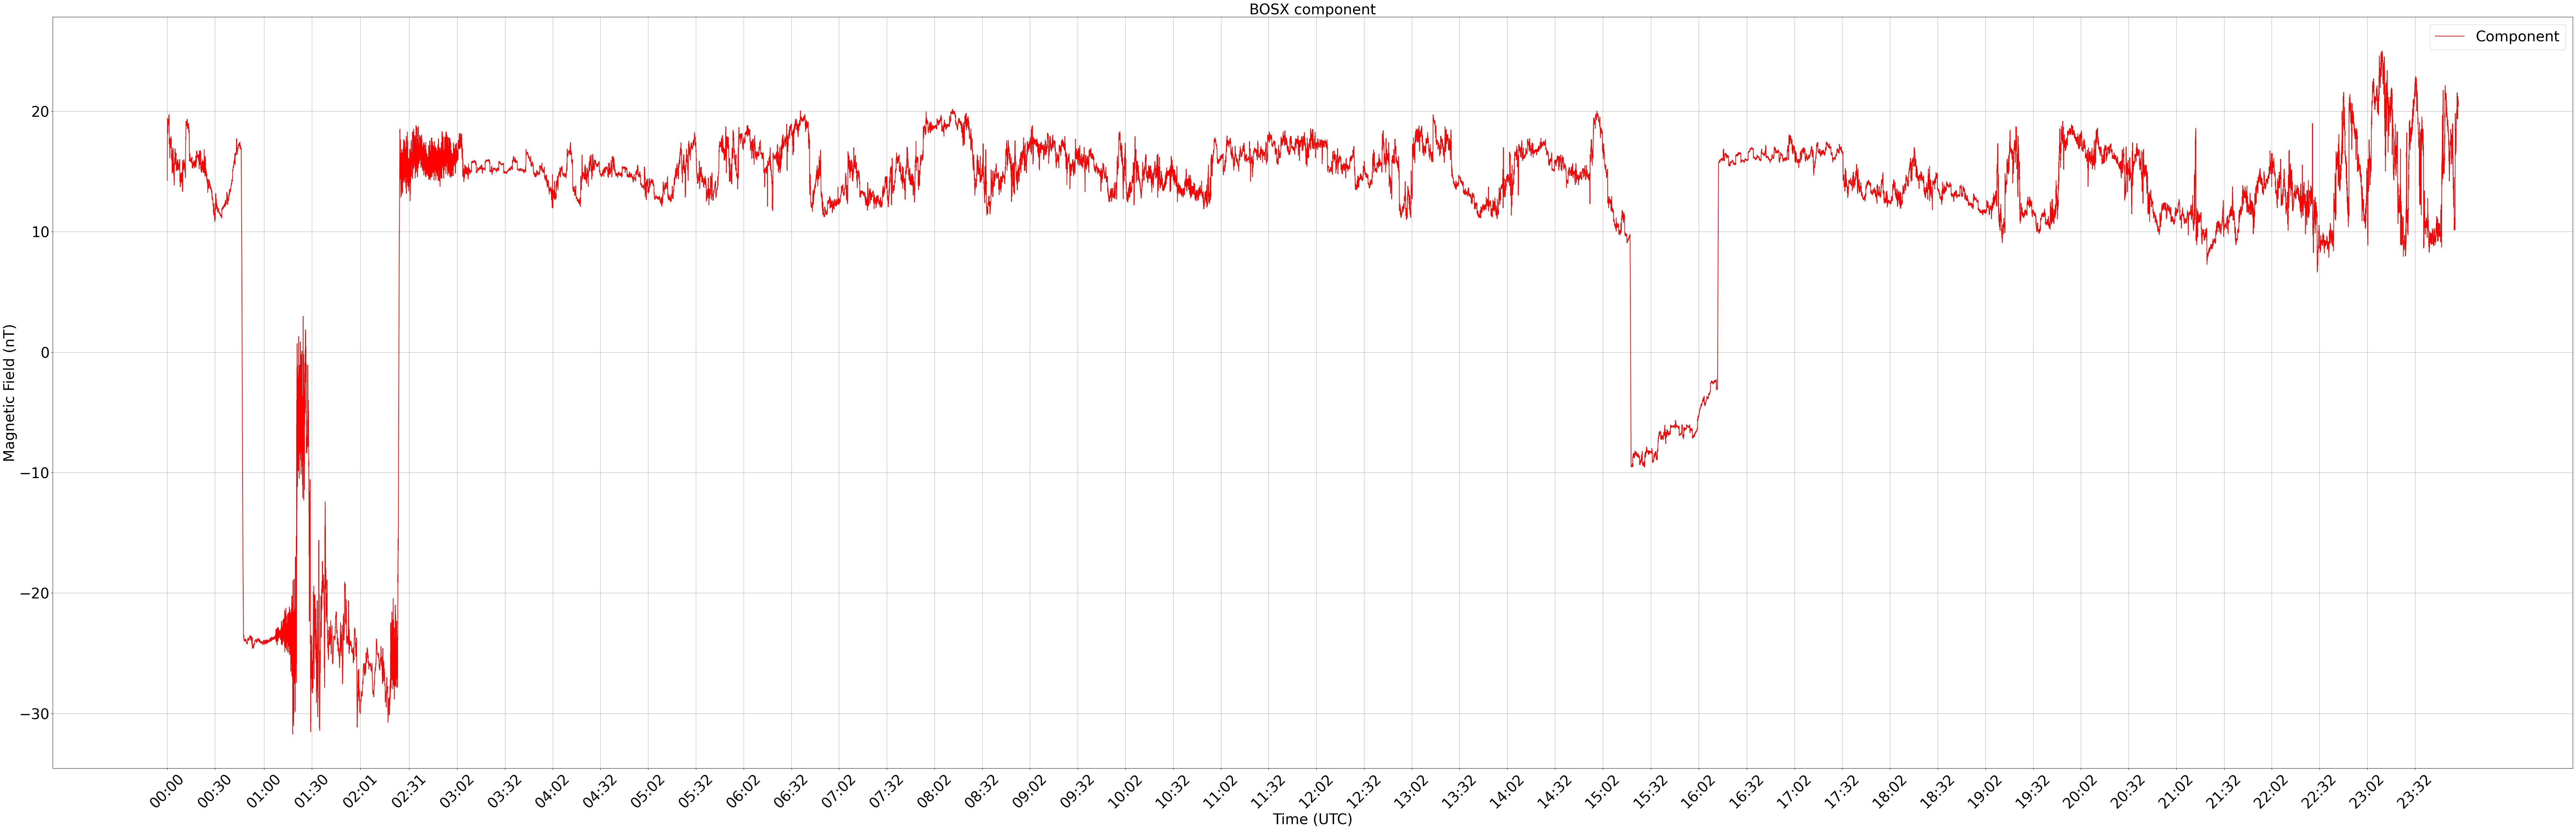

2025-06-18 00:13:11,655 - INFO - Plotting component and saving to ../data/assets/BOSY.png


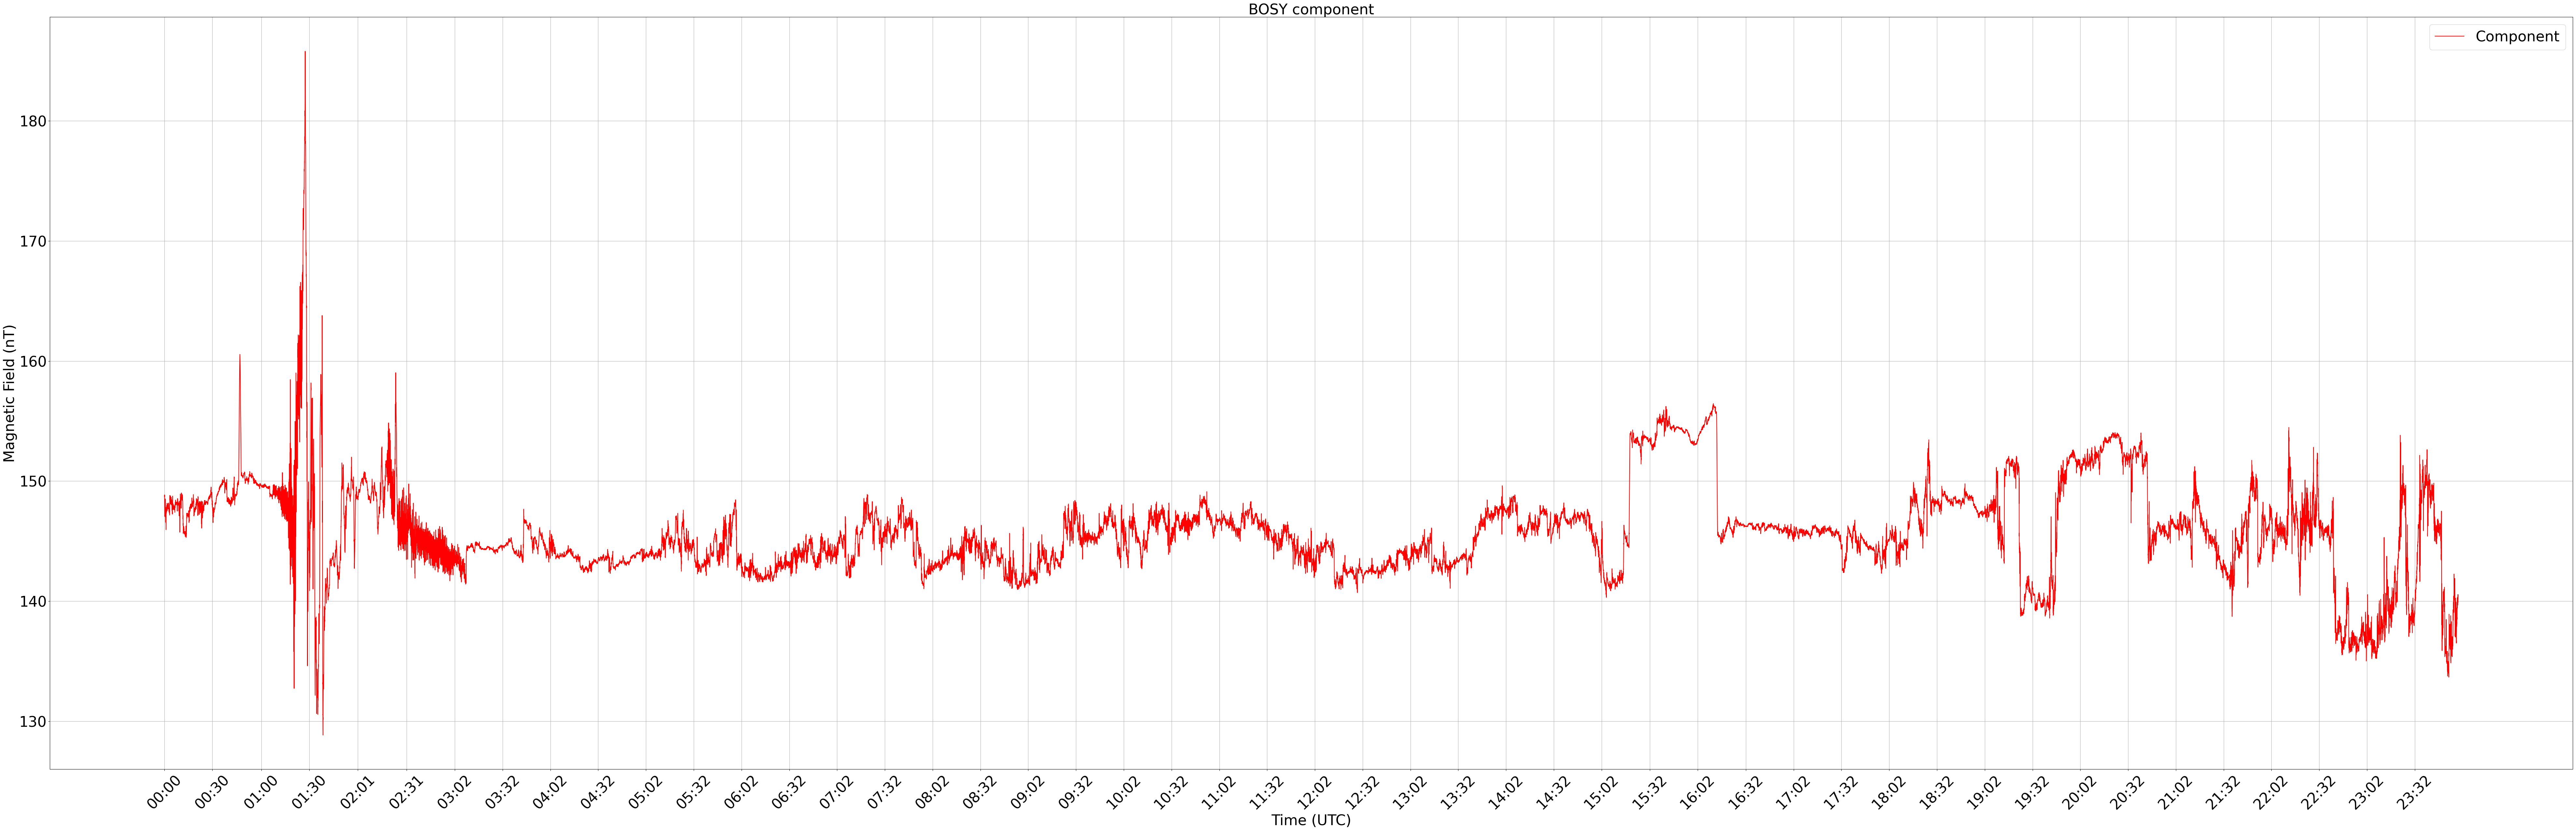

2025-06-18 00:13:13,601 - INFO - Plotting component and saving to ../data/assets/BOSZ.png


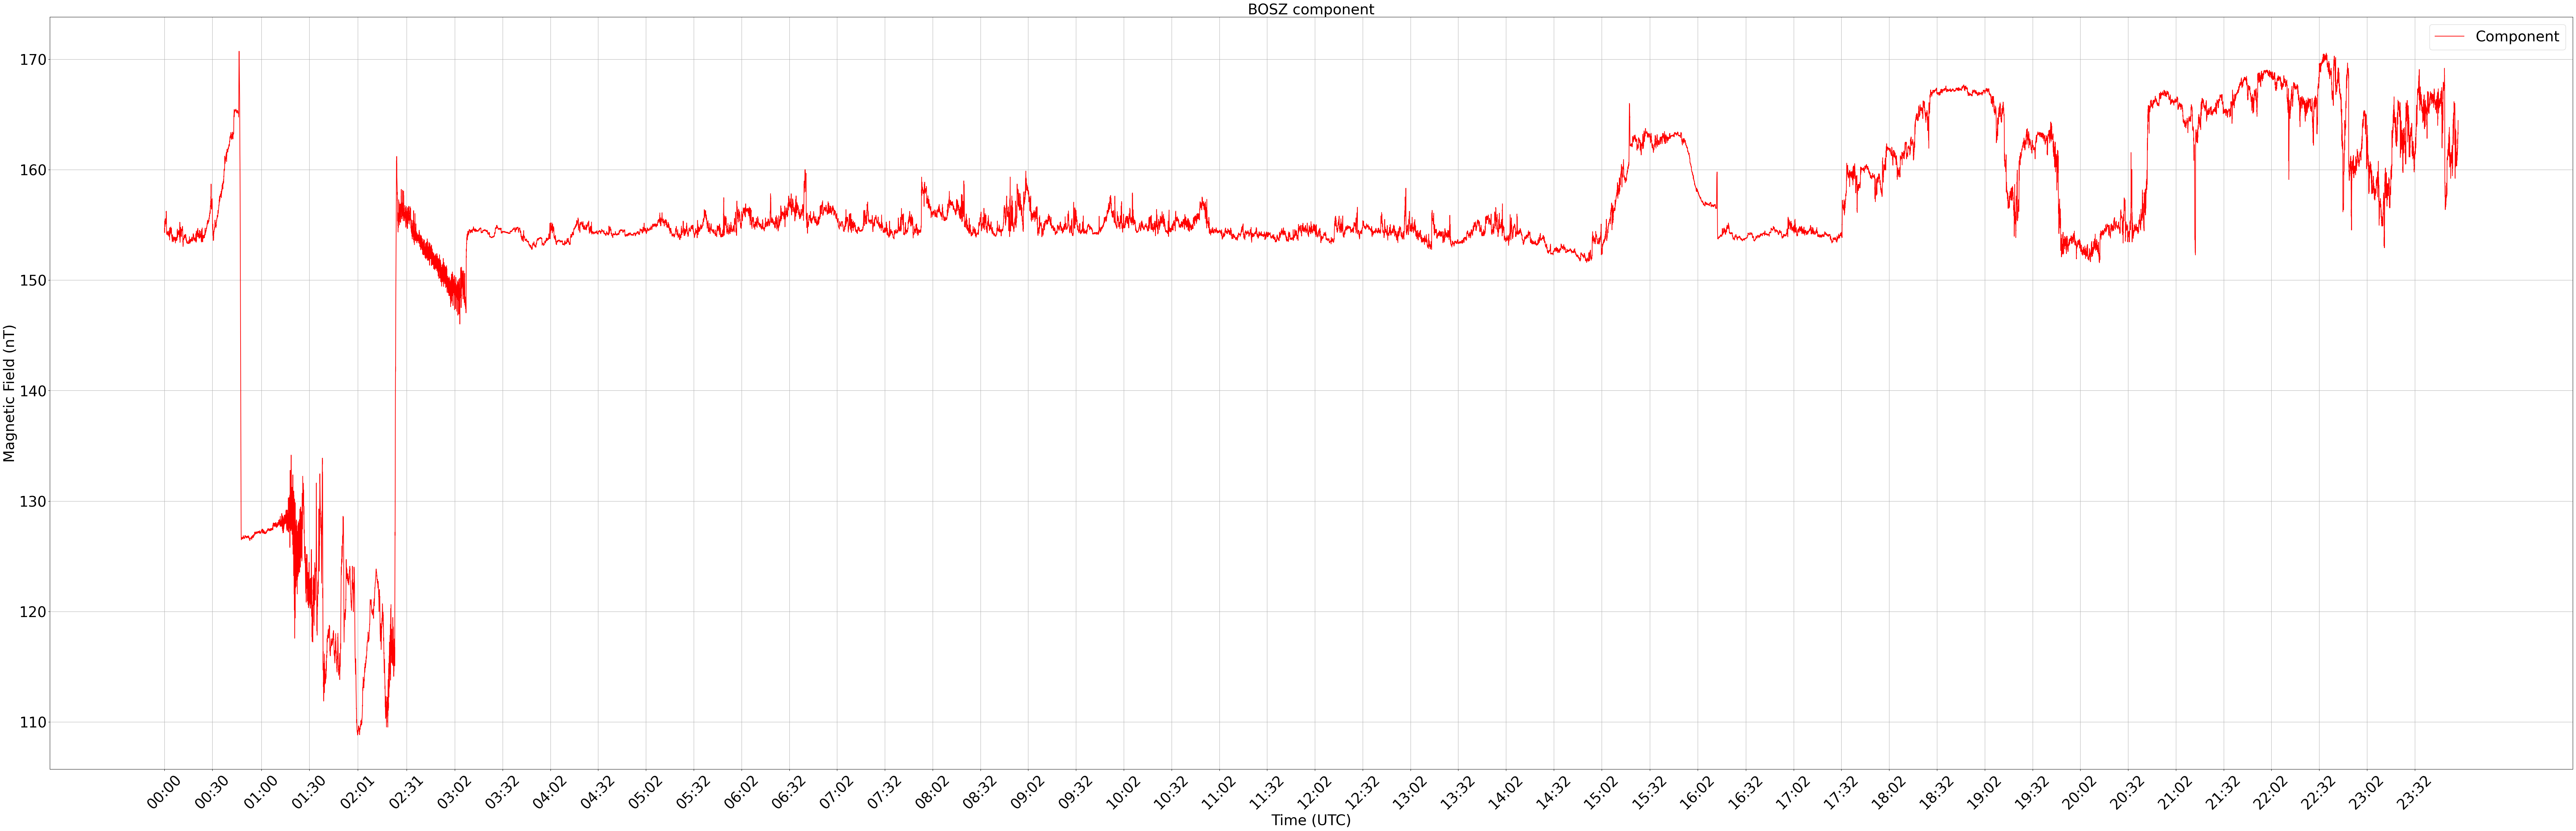

2025-06-18 00:13:15,569 - INFO - Plotting component and saving to ../data/assets/BIS_BOS_T.png


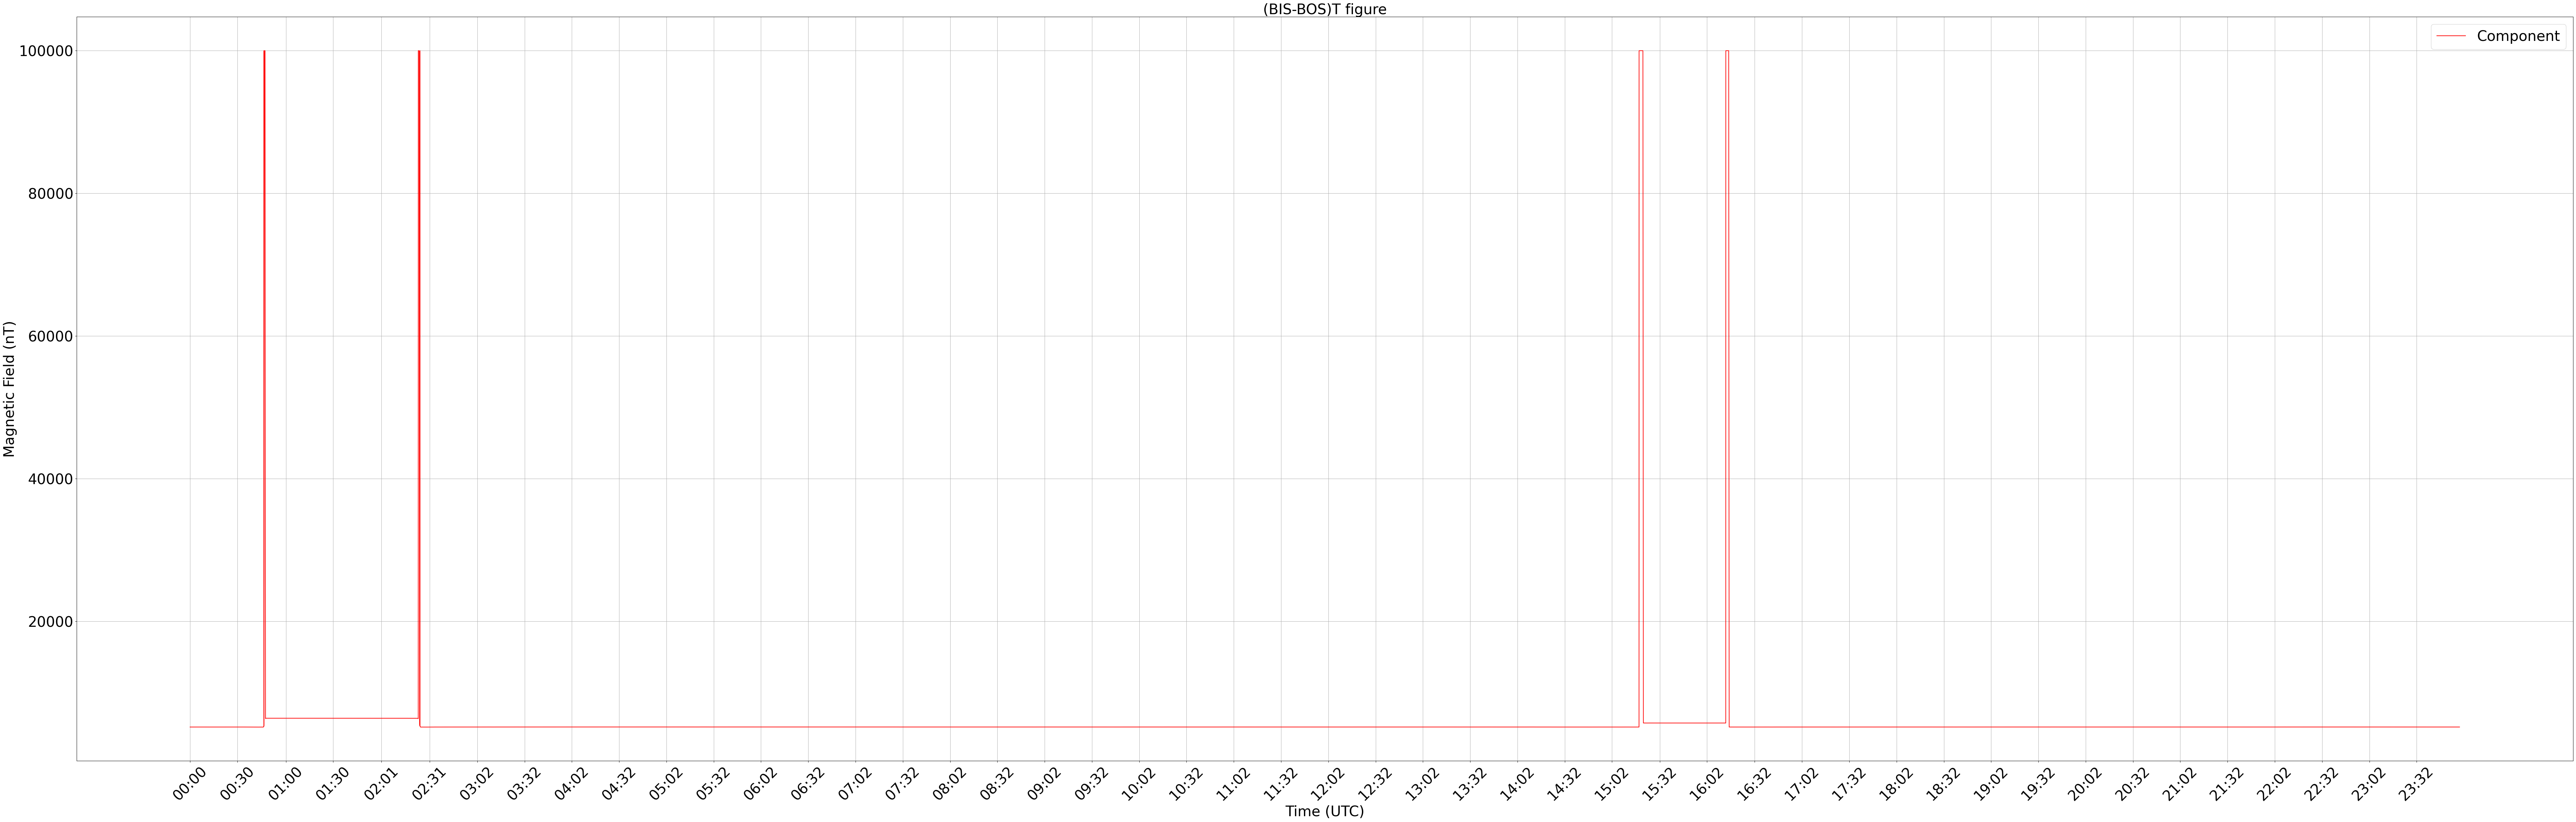

2025-06-18 00:13:17,364 - INFO - Plots generated successfully.


In [16]:
# Plotting originals
plot_component(TIME_UTC, BOSX, "BOSX component", '../data/assets/BOSX.png')
plot_component(TIME_UTC, BOSY, "BOSY component", '../data/assets/BOSY.png')
plot_component(TIME_UTC, BOSZ, "BOSZ component", '../data/assets/BOSZ.png')
plot_component(TIME_UTC, BIS_BOS_T, "(BIS-BOS)T figure", '../data/assets/BIS_BOS_T.png')
logging.info("Plots generated successfully.")

In [8]:
# High-frequency filter
def filtro_pasa_bajas(signal_data: list[float] | np.ndarray, R: float, C: float, sampling_rate: float) -> np.ndarray:
    """
    Modela un filtro pasa bajas RC utilizando scipy.signal.

    :param signal_data (list or np.array): Lista de flotantes representando la señal de entrada.
    :param R (float): Resistencia en Ohms.
    :param C (float): Capacitancia en Faradios.
    :param sampling_rate (float): Frecuencia de muestreo de la señal en Hz.

    Returns:
        list  or np.array: Señal filtrada de salida.
    """
    # Calcula la frecuencia de corte del filtro RC
    f_c = 1 / (2 * np.pi * R * C)
    
    # Normaliza la frecuencia de corte con respecto a la frecuencia de Nyquist
    # (f_nyquist = sampling_rate / 2)
    nyquist_freq = 0.5 * sampling_rate
    normalized_cutoff_freq = f_c / nyquist_freq

    # Diseña el filtro Butterworth de primer orden
    # 'b' son los coeficientes del numerador, 'a' son los coeficientes del denominador
    b, a = sg.butter(1, normalized_cutoff_freq, btype='low', analog=False)  # type: ignore

    # Aplica el filtro a la señal de entrada
    # 'filtfilt' aplica el filtro hacia adelante y hacia atrás para evitar el desfase de fase
    # Si quieres ver el desfase que introduciría el filtro, usa signal.lfilter en su lugar
    signal_array = np.array(signal_data)
    filtered_signal = sg.filtfilt(b, a, signal_array)
    
    return filtered_signal

In [9]:
def filtro_rechaza_banda(signal_data: list[float] | np.ndarray, lowcut: float, highcut: float, sampling_rate: float, order: int = 2) -> np.ndarray:
    """
    Aplica un filtro rechaza banda (notch/band-stop) Butterworth a la señal de entrada.

    :param signal_data: Señal de entrada (list o np.ndarray).
    :param lowcut: Frecuencia baja de corte (Hz).
    :param highcut: Frecuencia alta de corte (Hz).
    :param sampling_rate: Frecuencia de muestreo (Hz).
    :param order: Orden del filtro (por defecto 2).
    :return: Señal filtrada (np.ndarray).
    """
    nyquist = 0.5 * sampling_rate
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = sg.butter(order, [low, high], btype='bandstop')  #type: ignore
    signal_array = np.array(signal_data)
    filtered_signal = sg.filtfilt(b, a, signal_array)
    return filtered_signal

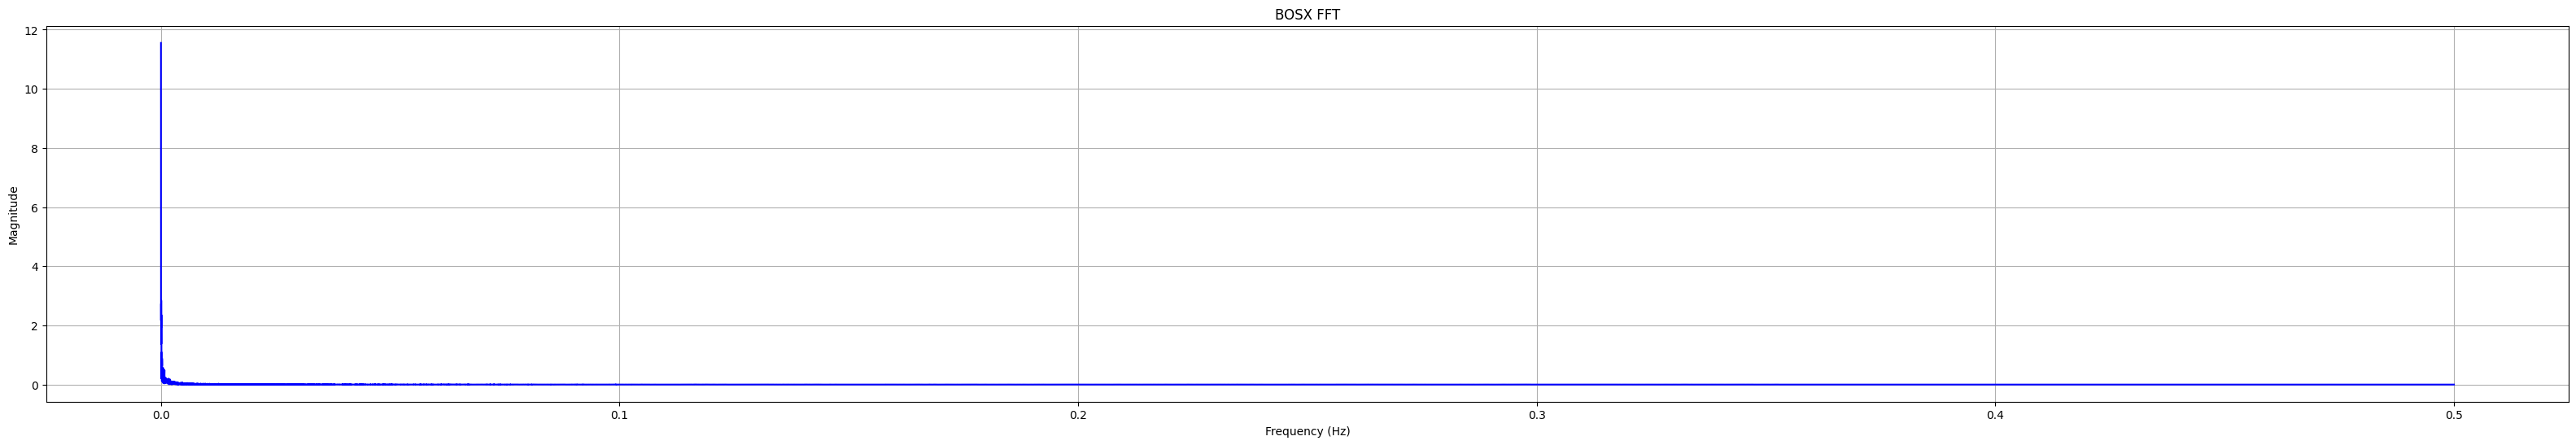

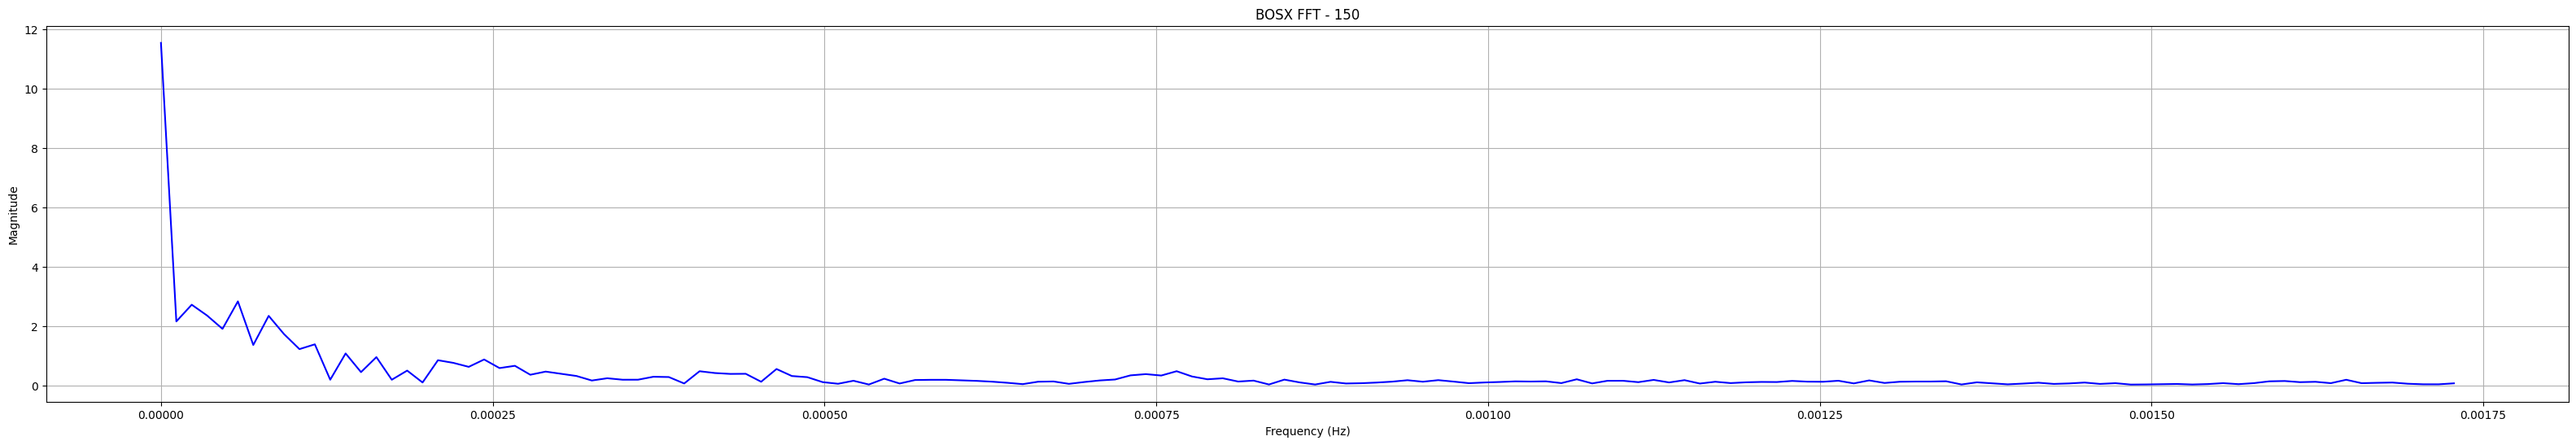

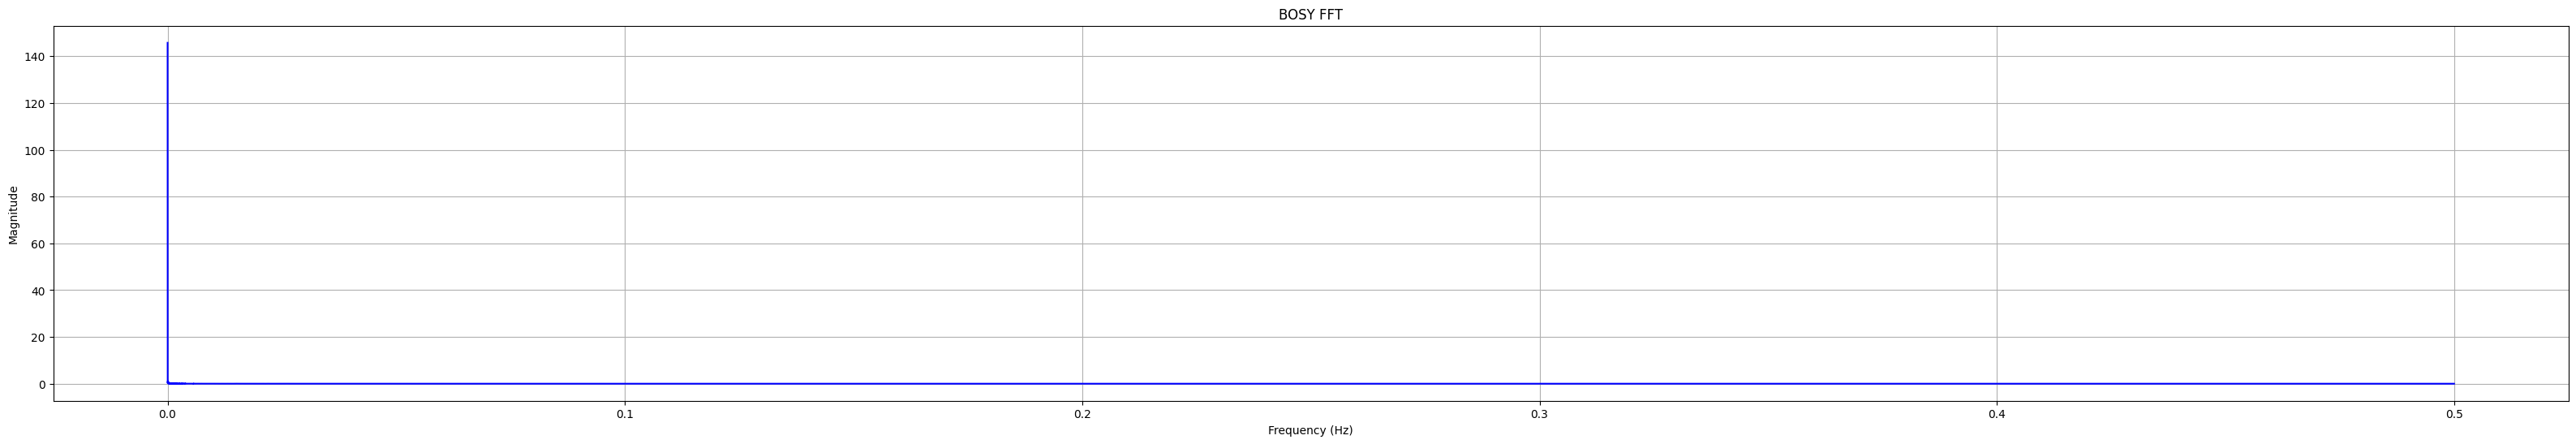

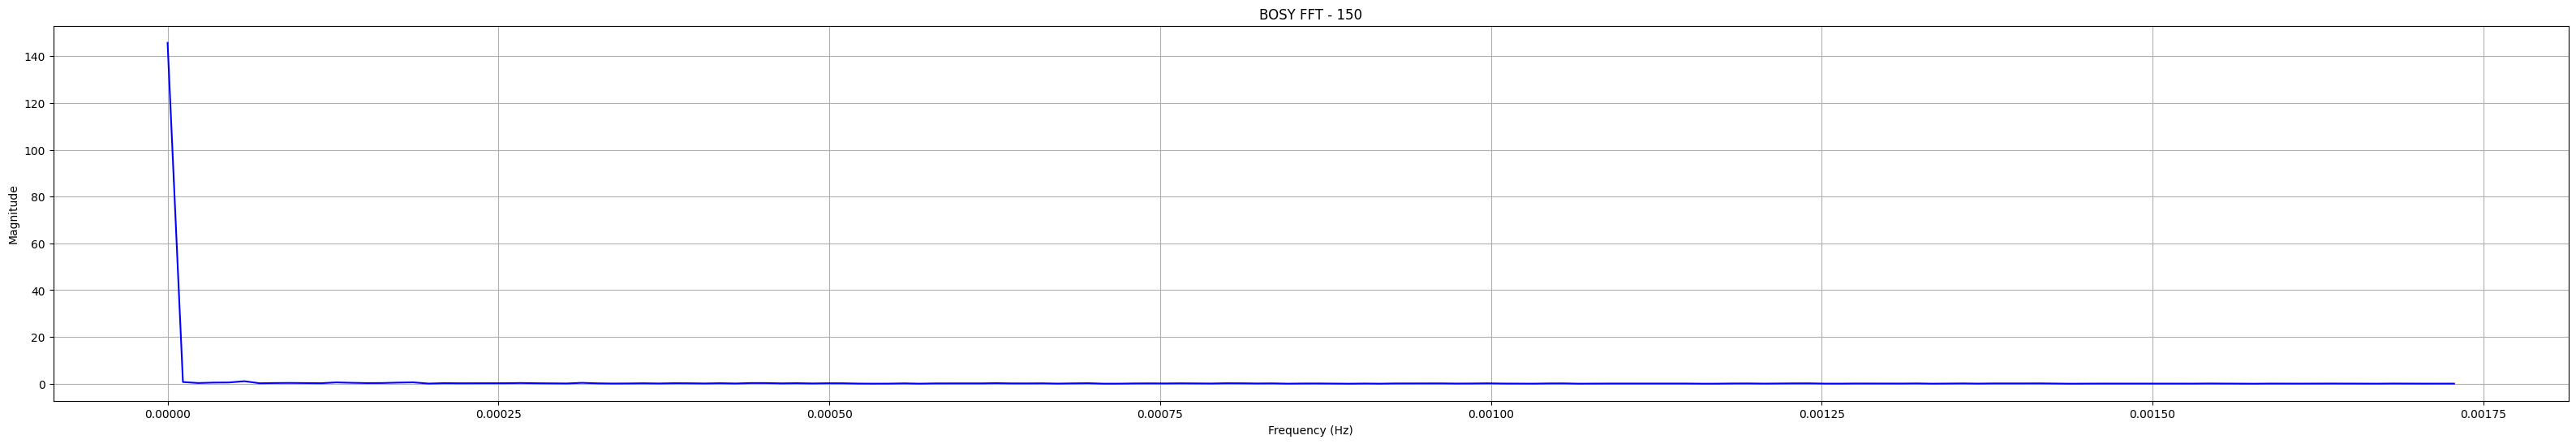

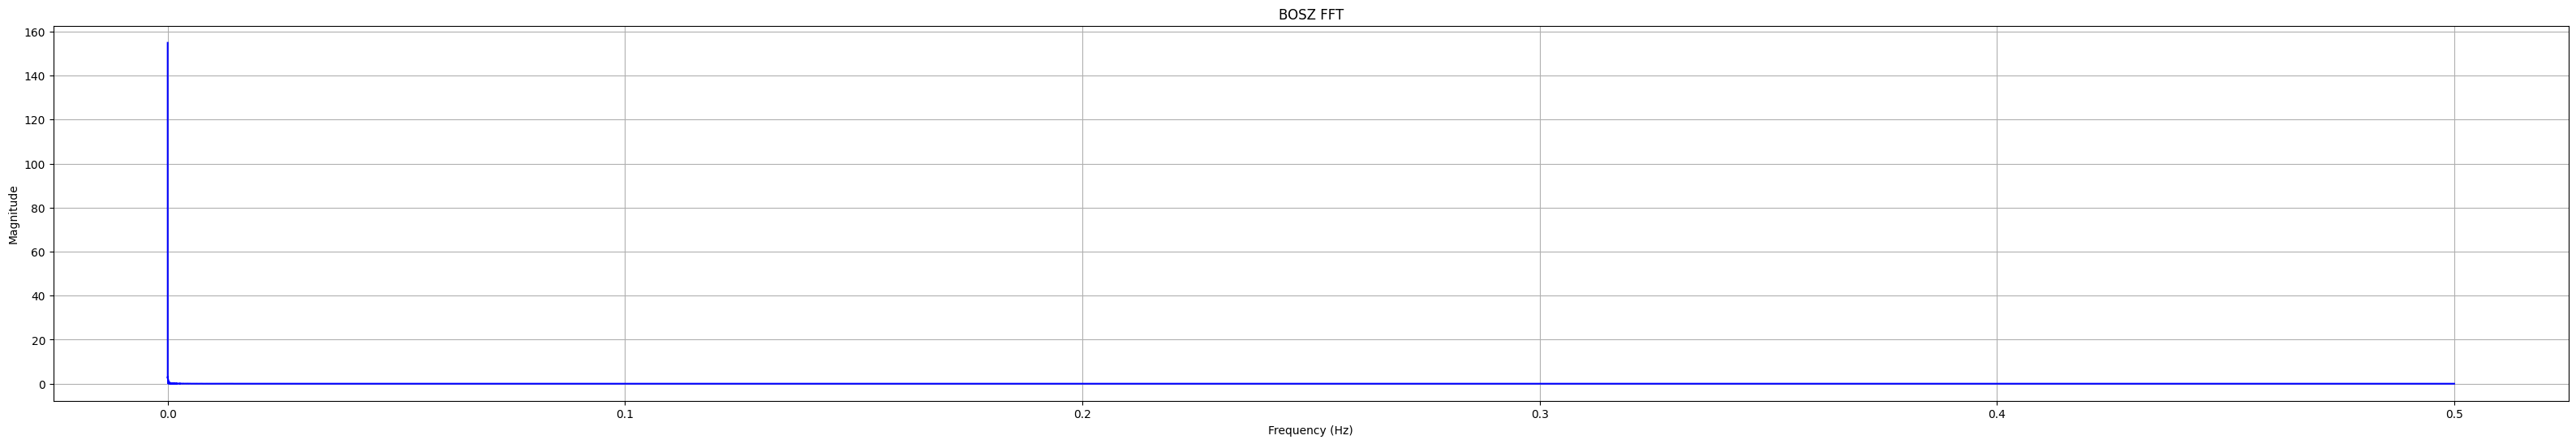

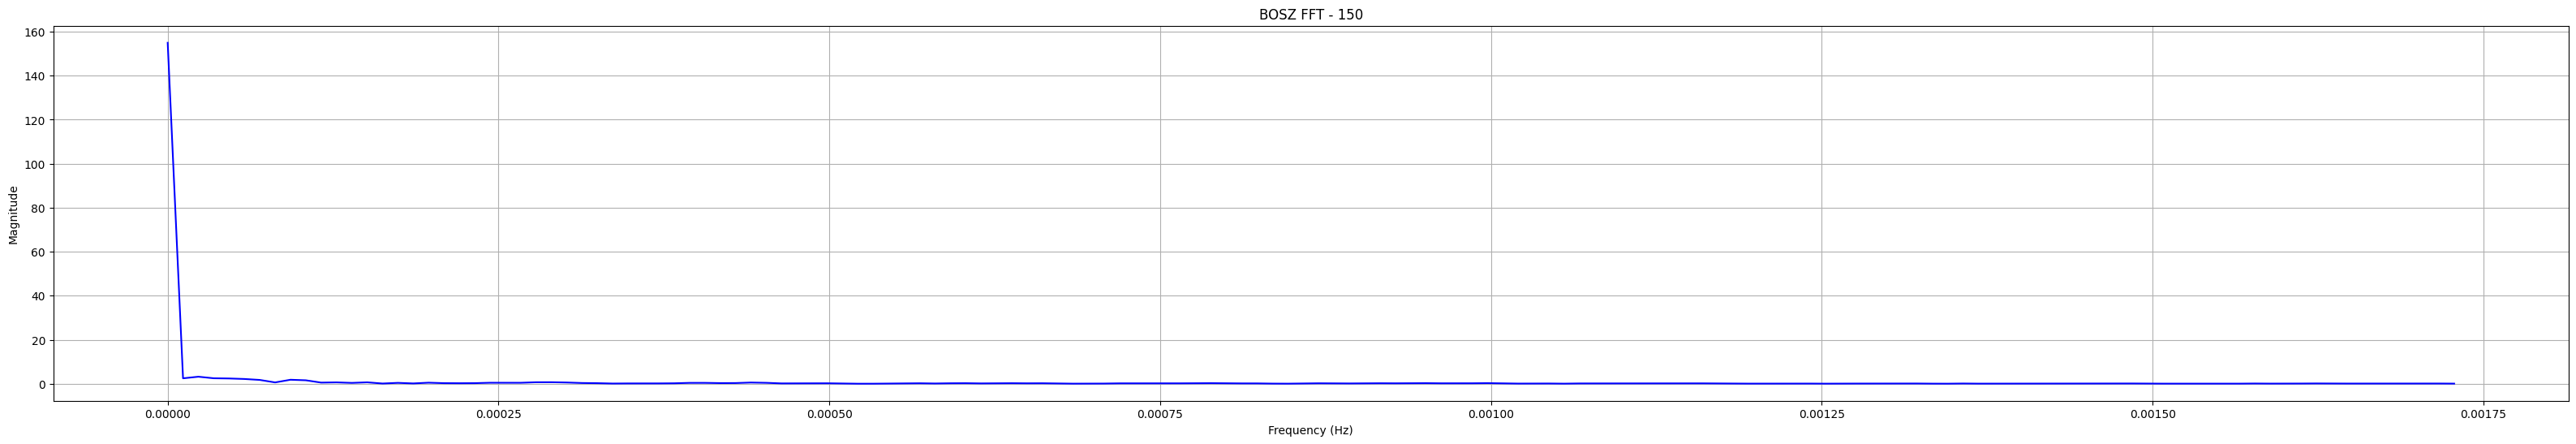

In [10]:
# Plotting frequency spectrum of each signal
partial: int = 150
for signal, component in zip([BOSX, BOSY, BOSZ], ['X', 'Y', 'Z']):
    frequencies, magnitudes = fast_fourier_transform(signal, TIME_UTC, 1.0)
    plot_frequency_spectrum(frequencies, magnitudes, f"BOS{component} FFT", f'../data/assets/frequency_spectrum/BOS{component}_FFT.png' )
    plot_frequency_spectrum(frequencies, magnitudes, f"BOS{component} FFT - {partial}", f'../data/assets/frequency_spectrum/BOS{component}_FFT_{partial}.png', partial)    

2025-06-18 00:38:52,551 - INFO - Datos calculados: 
R=1000000000.0.
C=2.2736420441699336e-06.
2025-06-18 00:38:52,581 - INFO - Plotting component and saving to ../data/assets/filtered/BOSX_high_frequency_filter.png


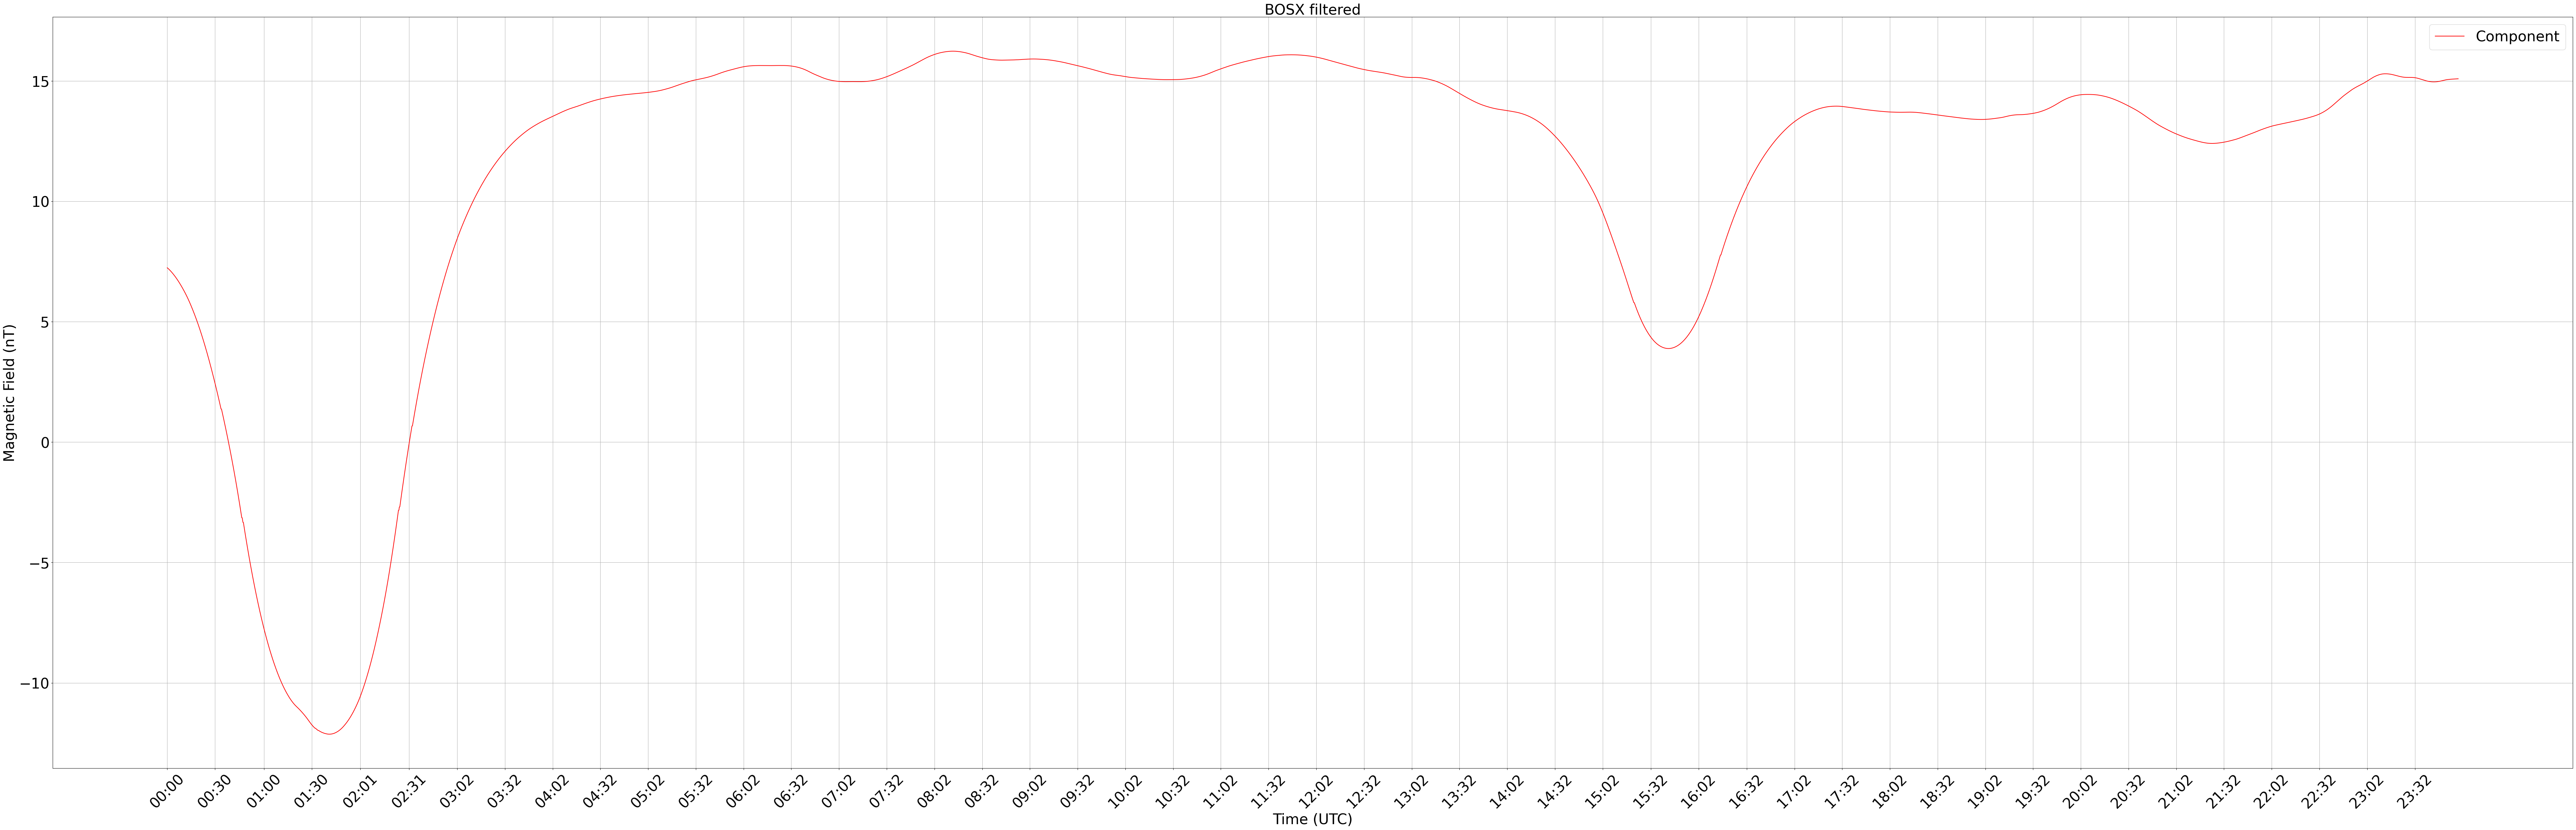

2025-06-18 00:38:54,361 - INFO - Plotting component and saving to ../data/assets/filtered/BOSY_high_frequency_filter.png


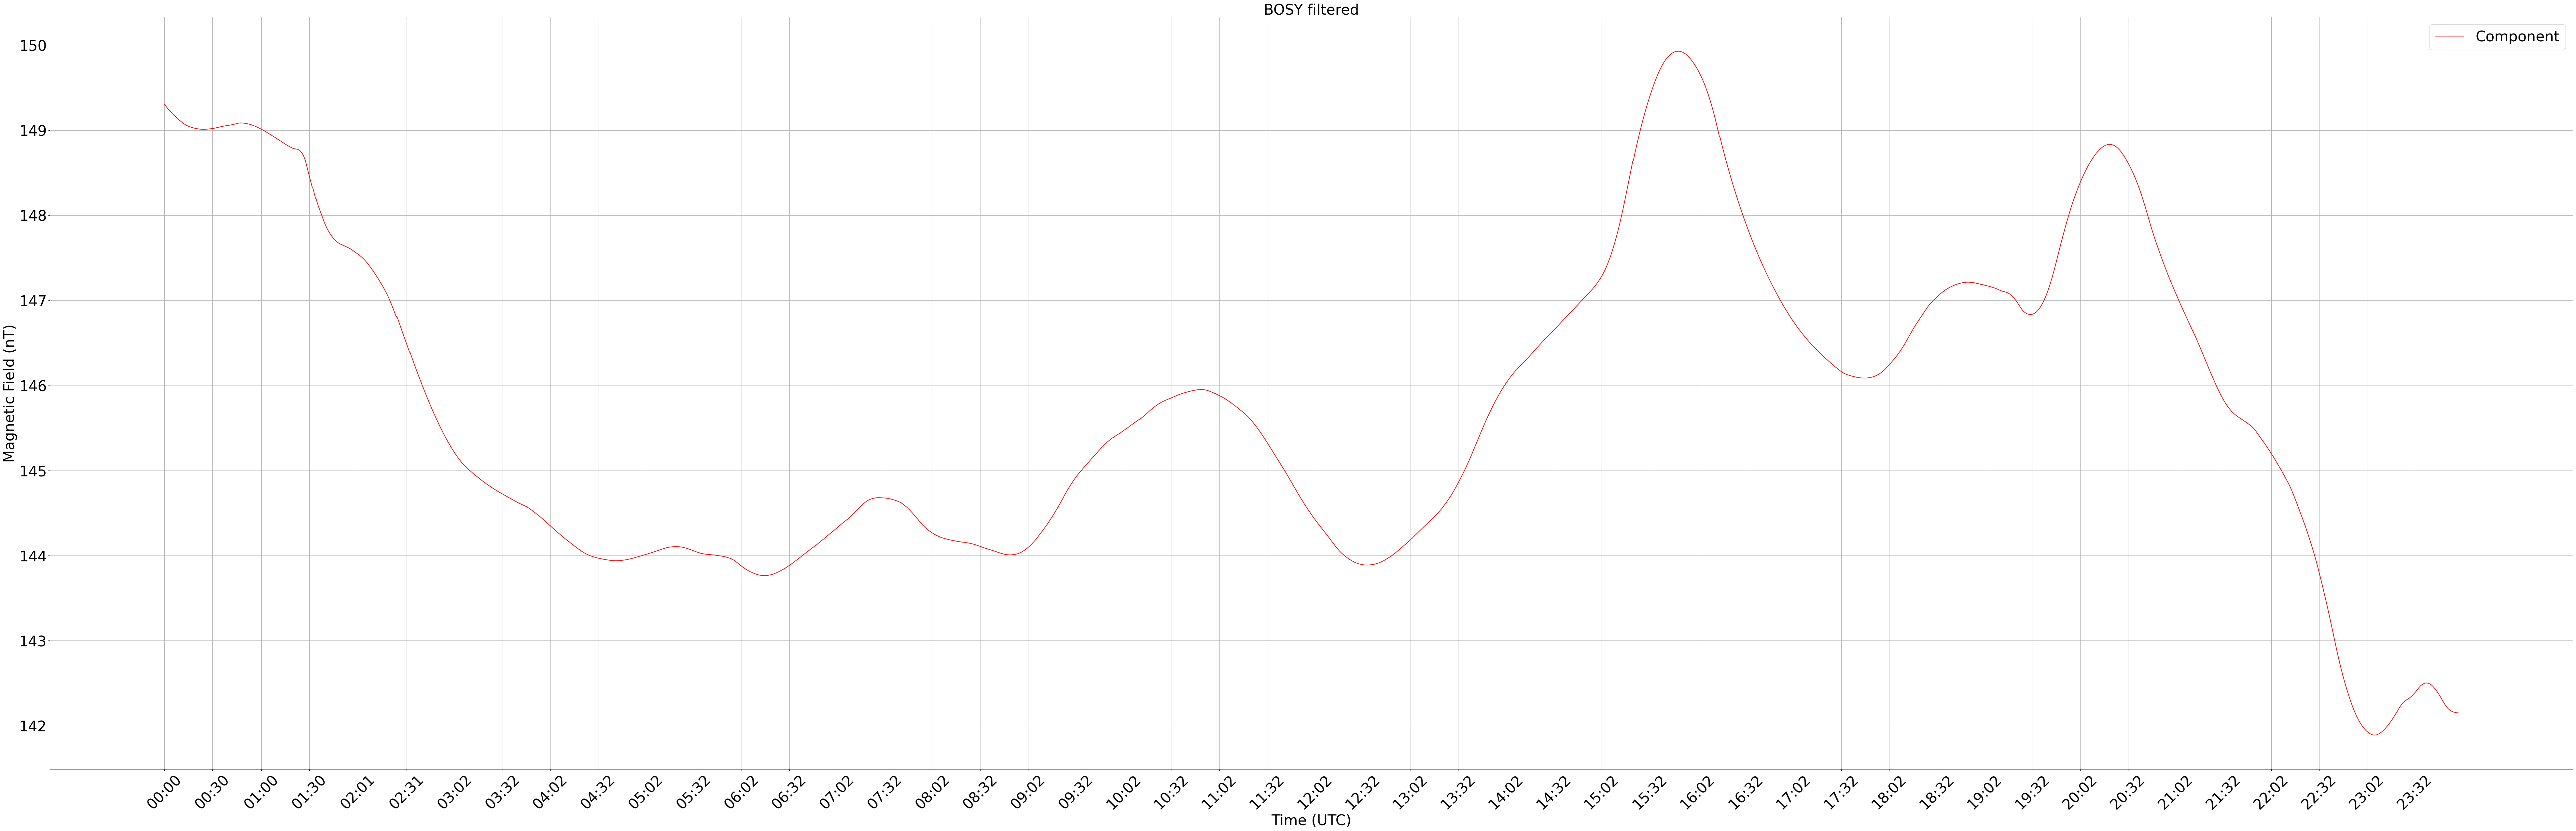

2025-06-18 00:38:56,121 - INFO - Plotting component and saving to ../data/assets/filtered/BOSZ_high_frequency_filter.png


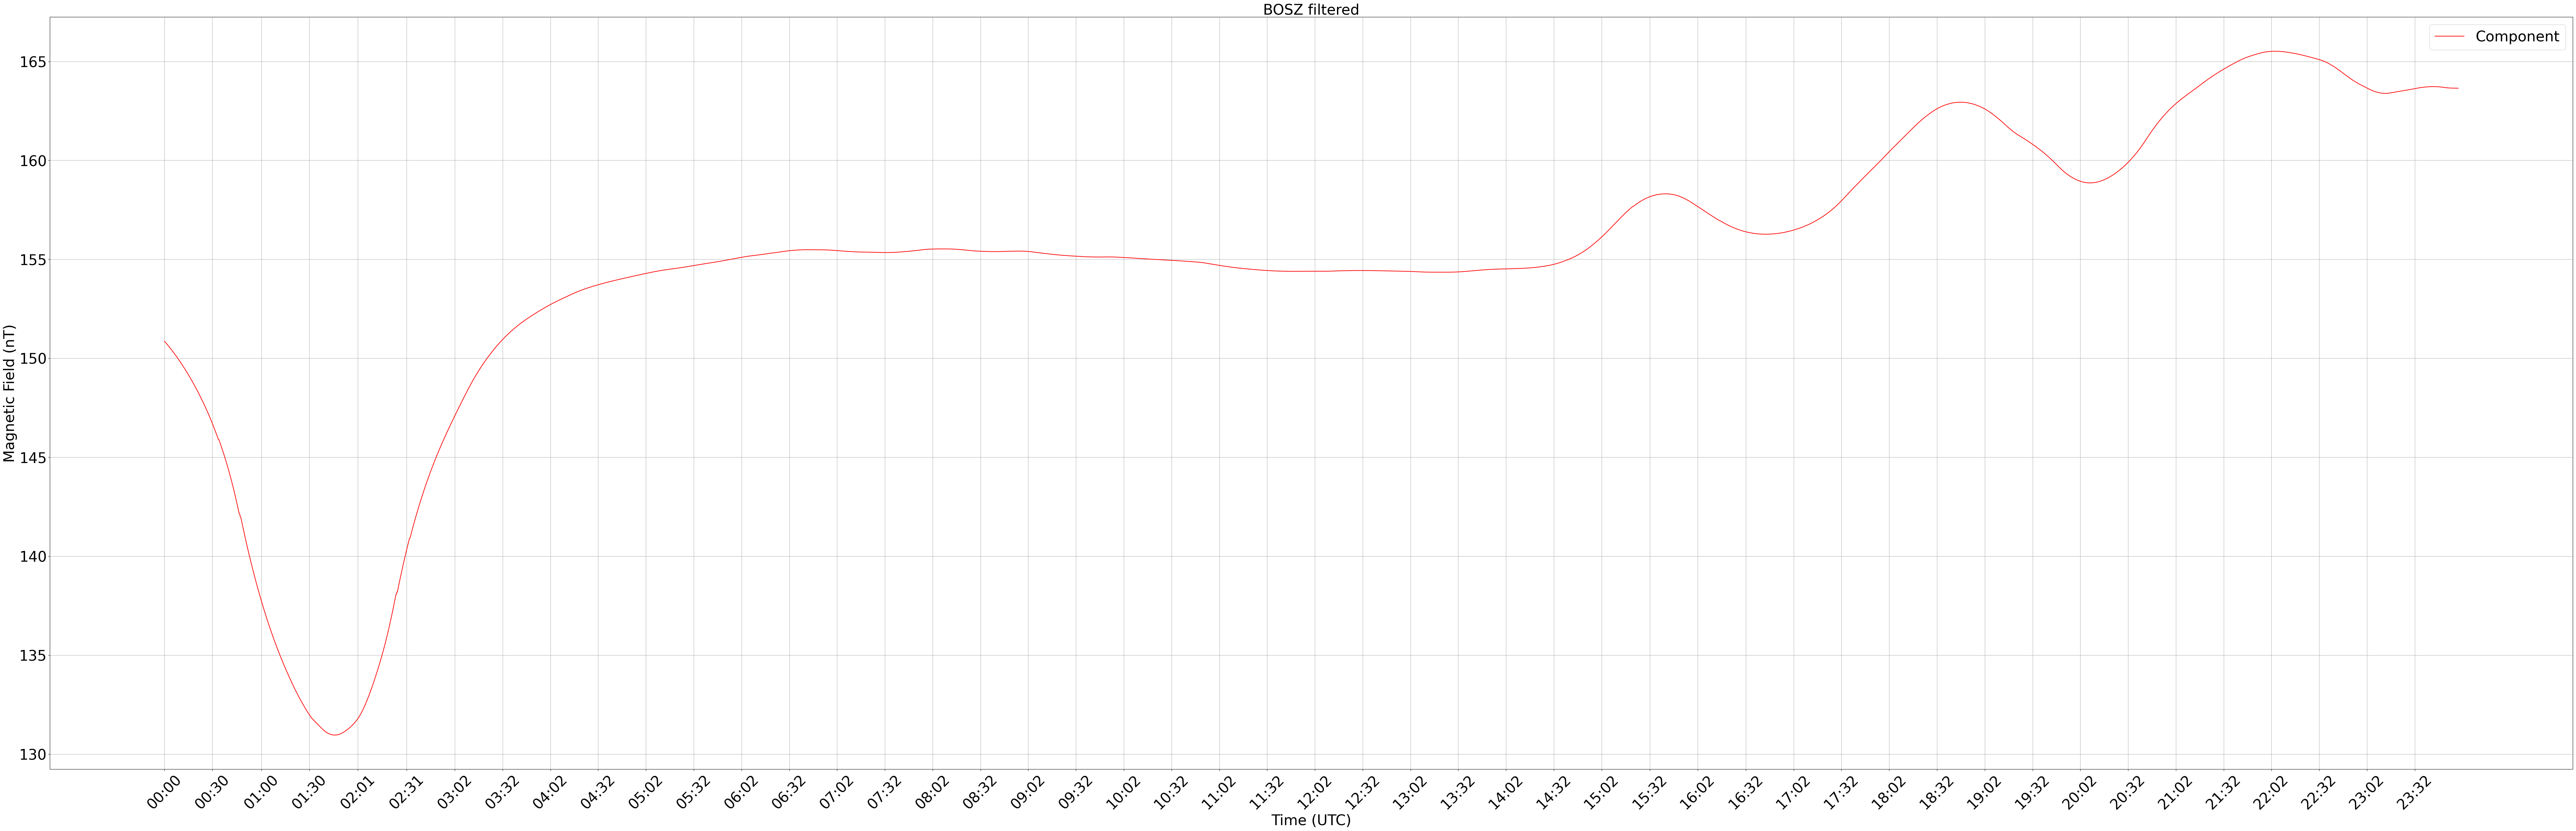

In [34]:
# Applying high-frequencies filter
sampling_rate:float = 1.0 # Los datos están registrados cada segundo
f_c: float = 7e-5 # Hz
R = 1e9 # 1T ohm
C = 1 / (2 * np.pi * R * f_c)
logging.info(f"Datos calculados: \n{R=}.\n{C=}.")
hff_BOSX: np.ndarray = filtro_pasa_bajas(BOSX, R, C, 1.0)
hff_BOSY: np.ndarray = filtro_pasa_bajas(BOSY, R, C, 1.0)
hff_BOSZ: np.ndarray = filtro_pasa_bajas(BOSZ, R, C, 1.0)
plot_component(TIME_UTC, list(hff_BOSX), "BOSX filtered", '../data/assets/filtered/BOSX_high_frequency_filter.png')
plot_component(TIME_UTC, list(hff_BOSY), "BOSY filtered", '../data/assets/filtered/BOSY_high_frequency_filter.png')
plot_component(TIME_UTC, list(hff_BOSZ), "BOSZ filtered", '../data/assets/filtered/BOSZ_high_frequency_filter.png')

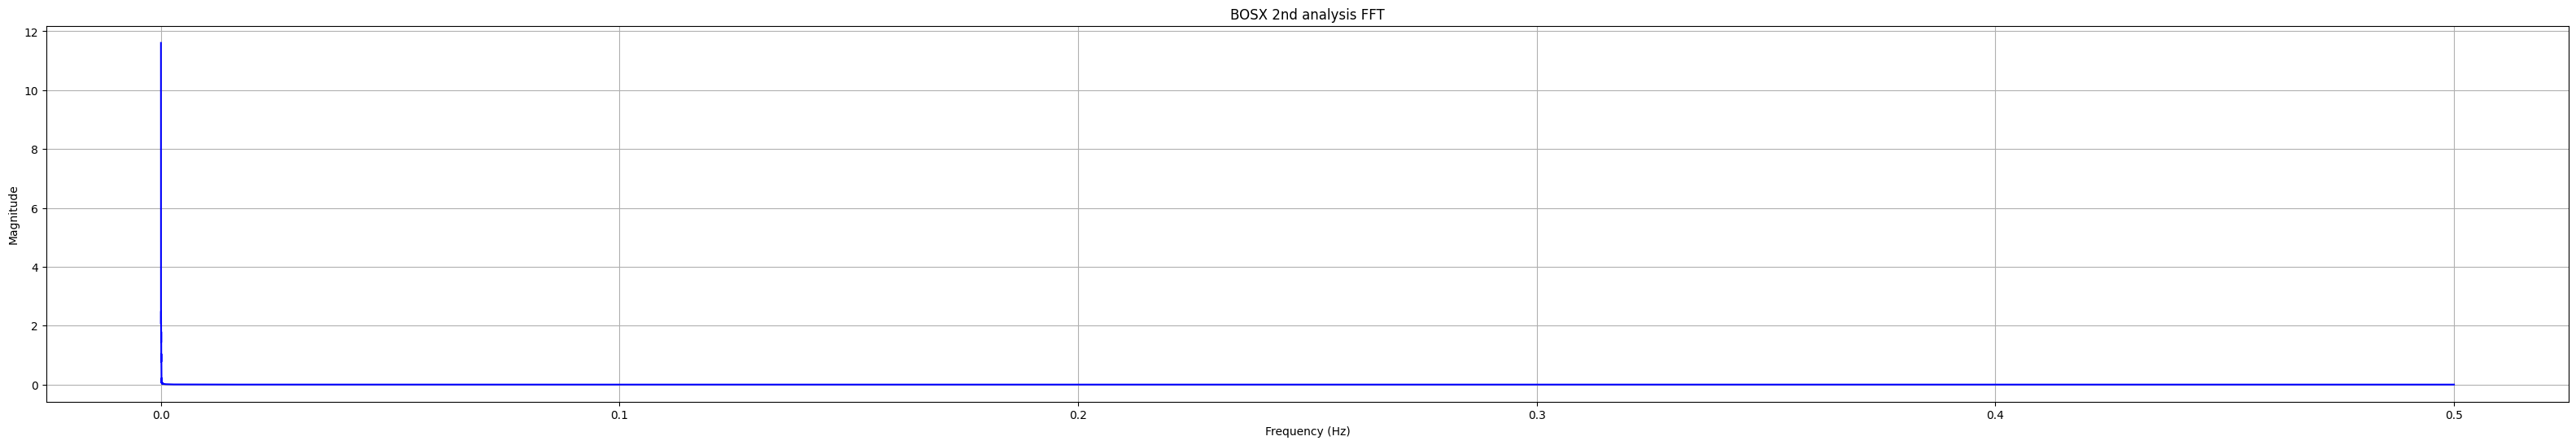

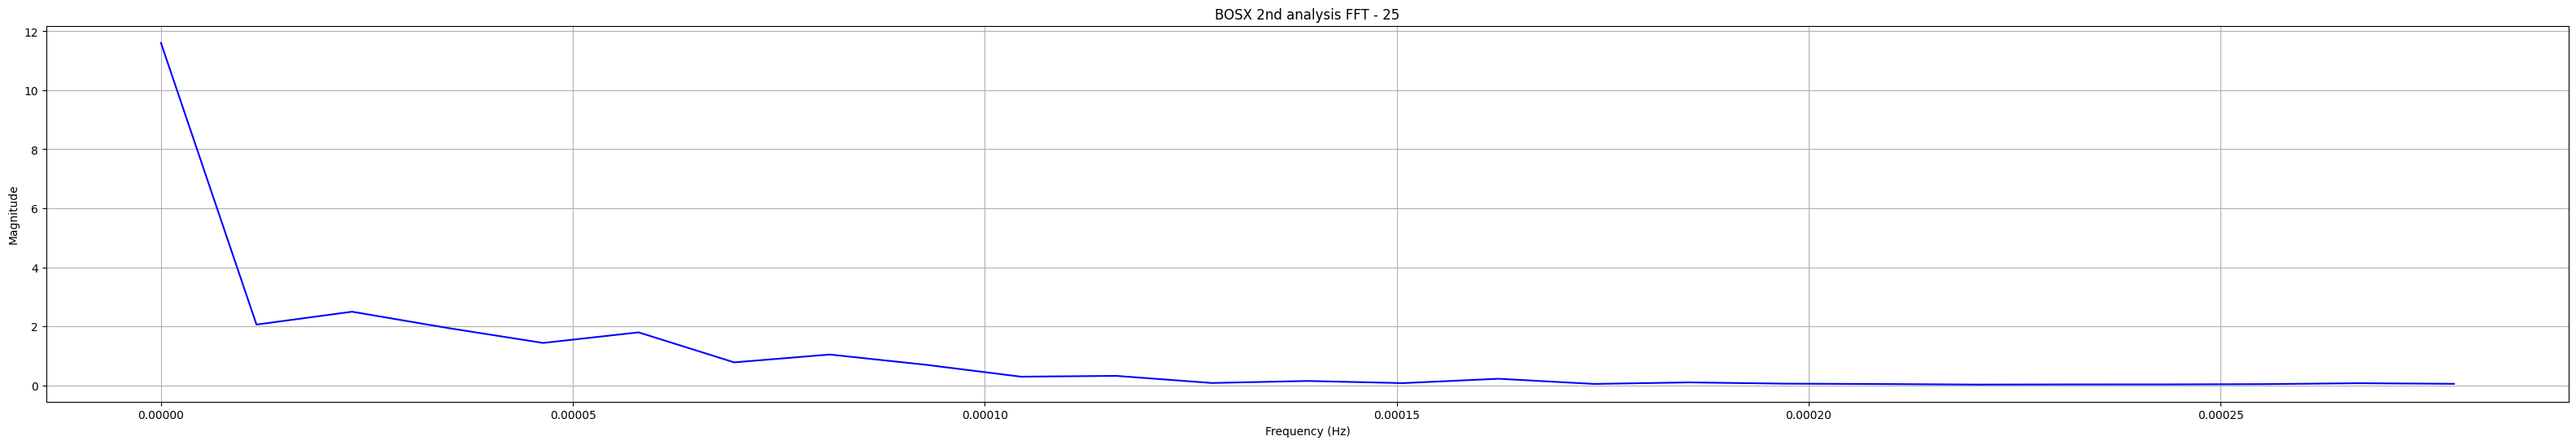

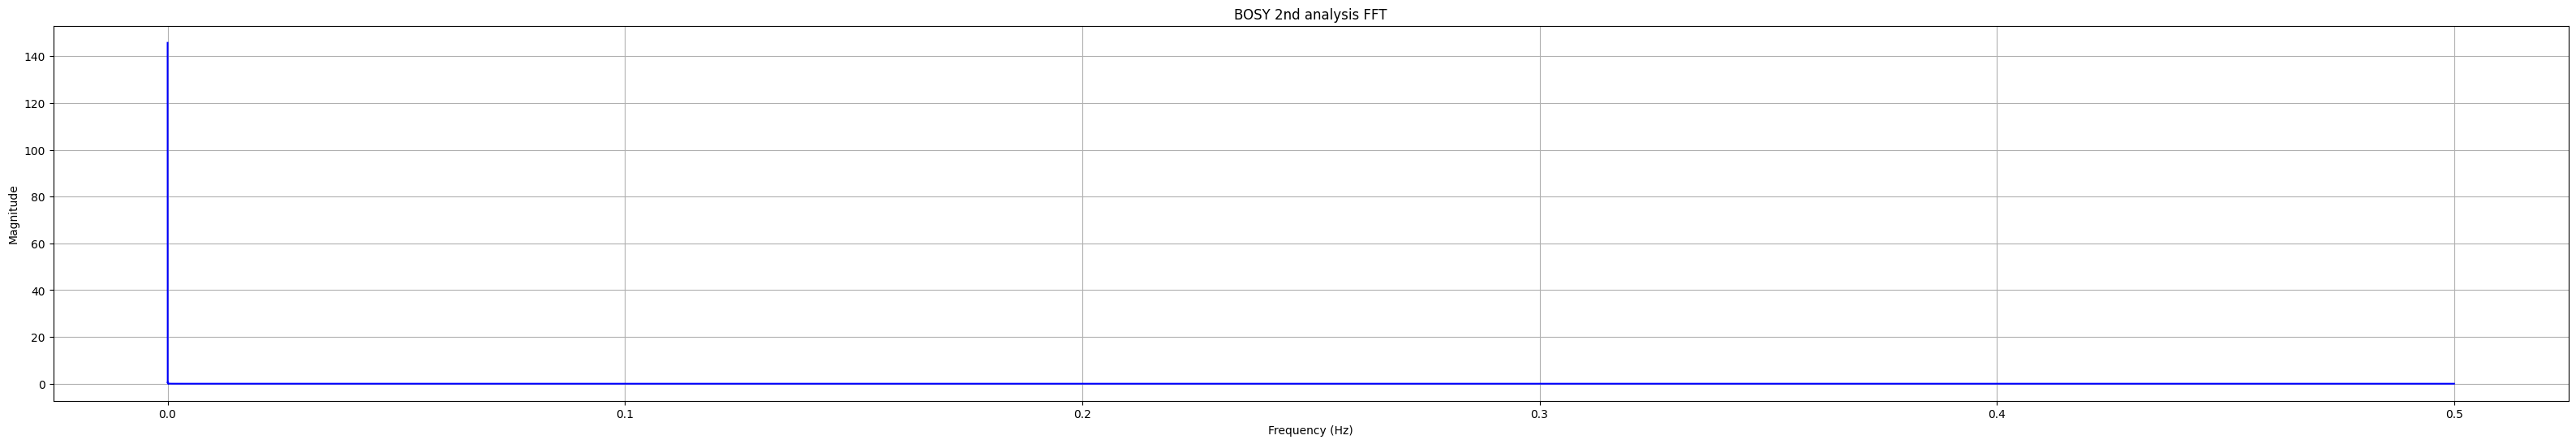

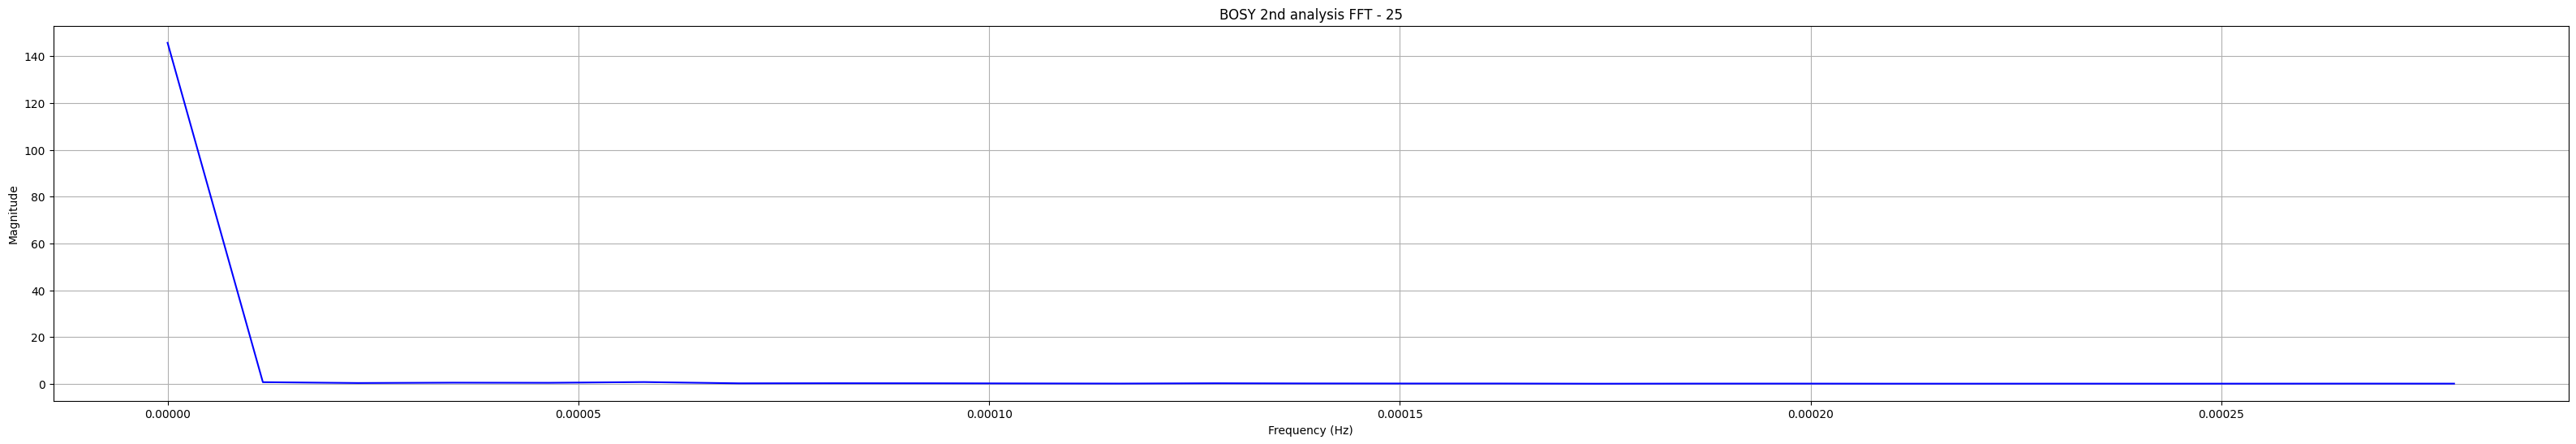

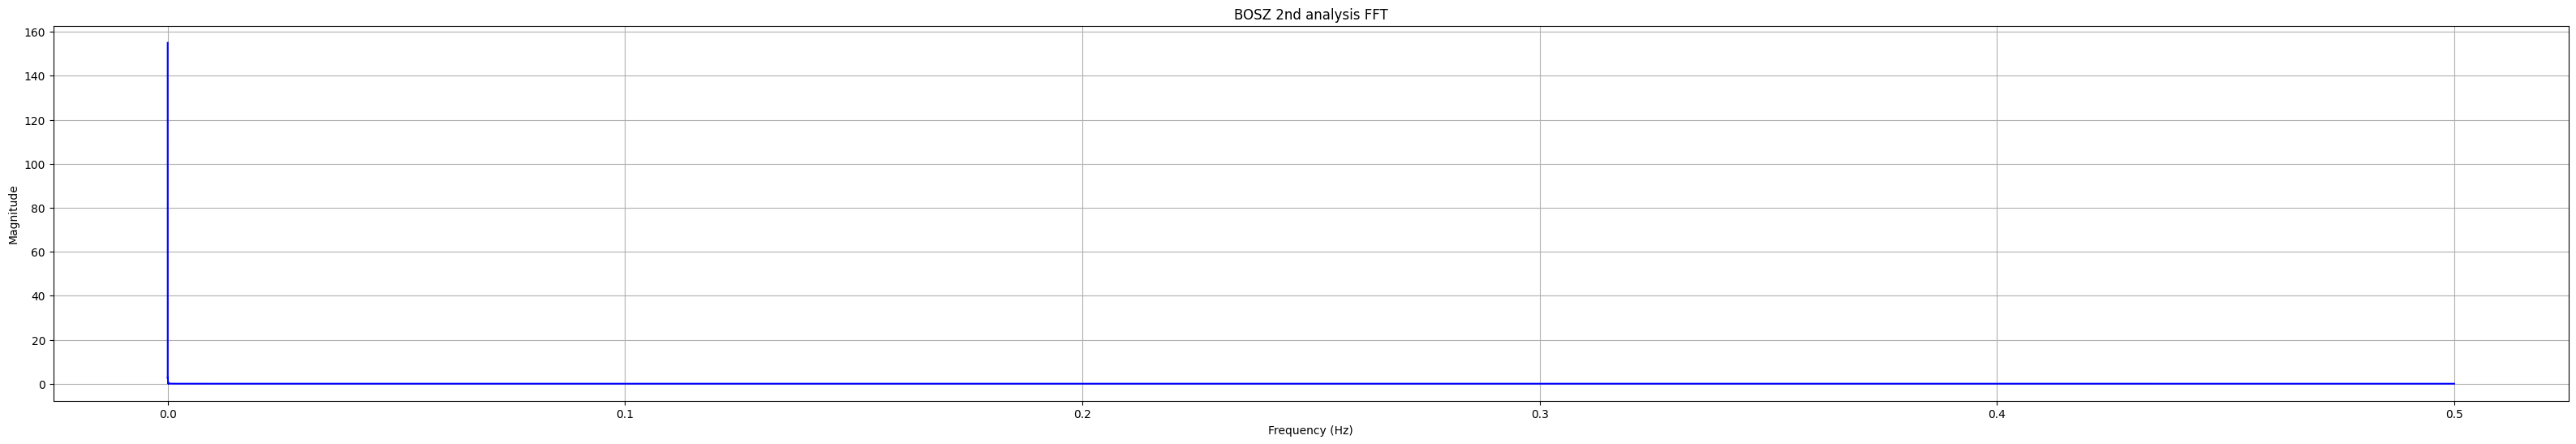

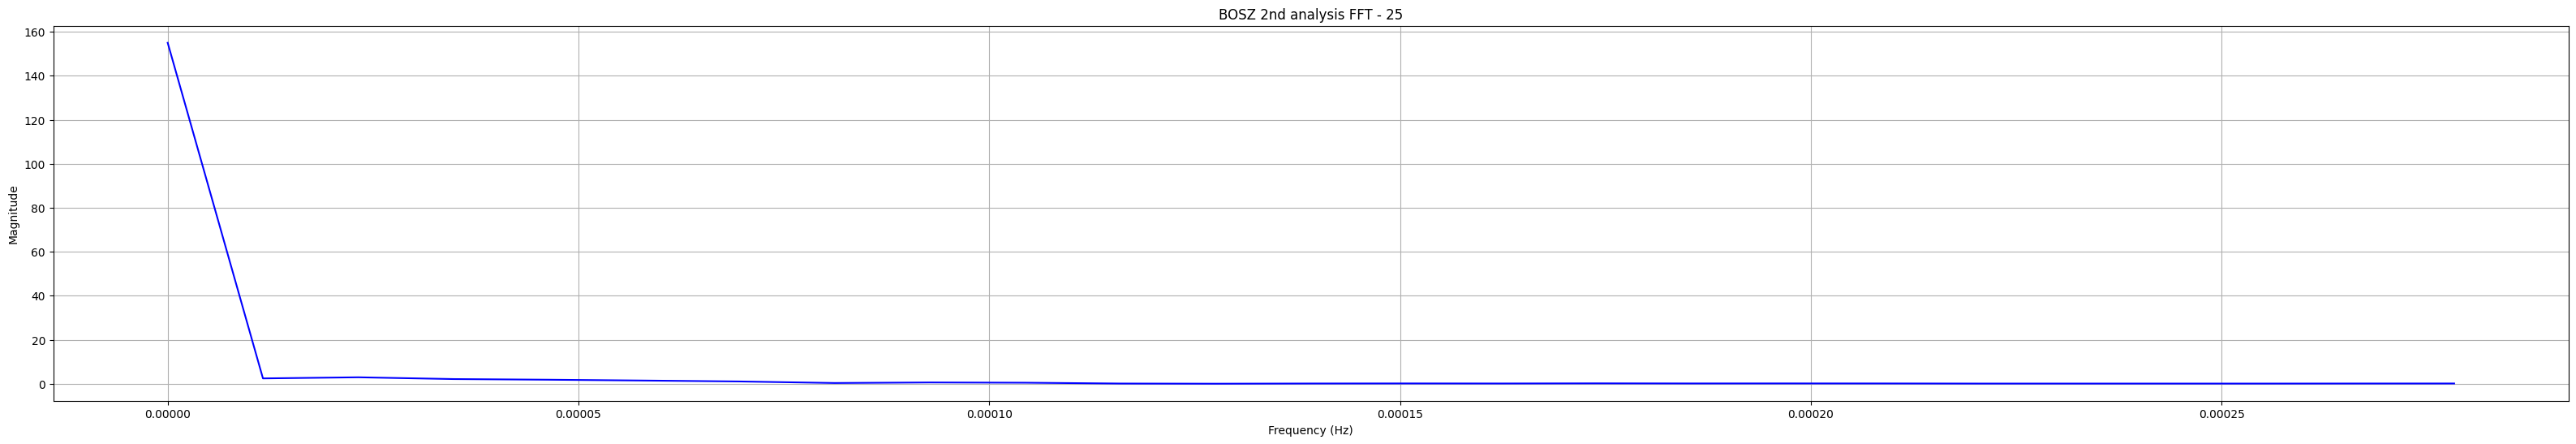

In [35]:
# Analysing post-filtering frequencies
partial = 25
for signal, component in zip([hff_BOSX, hff_BOSY, hff_BOSZ], ['X', 'Y', 'Z']):
    frequencies, magnitudes = fast_fourier_transform(list(signal), TIME_UTC, 1.0)
    plot_frequency_spectrum(frequencies, magnitudes, f"BOS{component} 2nd analysis FFT", f'../data/assets/frequency_spectrum/BOS{component}_FFT_hff.png' )
    plot_frequency_spectrum(frequencies, magnitudes, f"BOS{component} 2nd analysis FFT - {partial}", f'../data/assets/frequency_spectrum/BOS{component}_FFT_hff_{partial}.png', partial)

2025-06-18 01:40:32,348 - INFO - Plotting component and saving to ../data/assets/filtered/BOSX_band_stop_filter.png


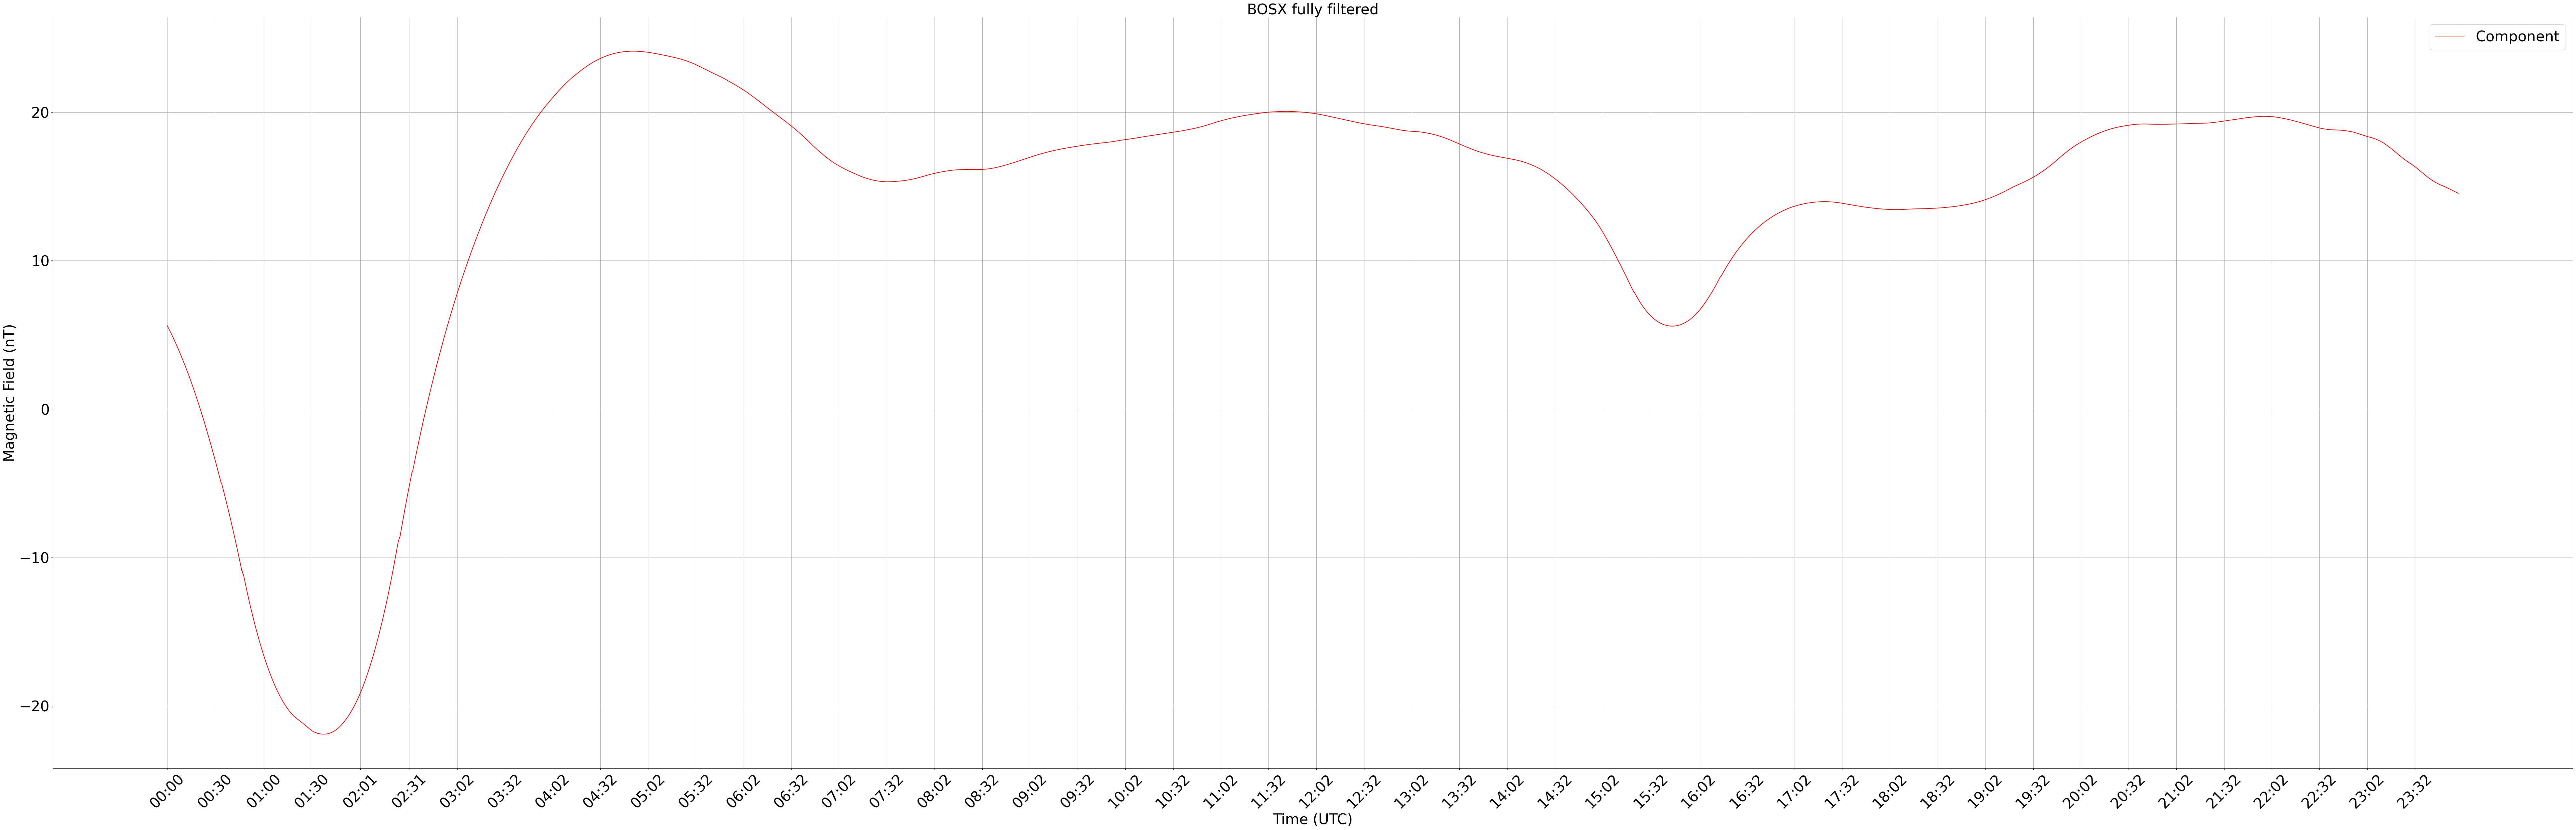

2025-06-18 01:40:34,060 - INFO - Plotting component and saving to ../data/assets/filtered/BOSY_band_stop_filter.png


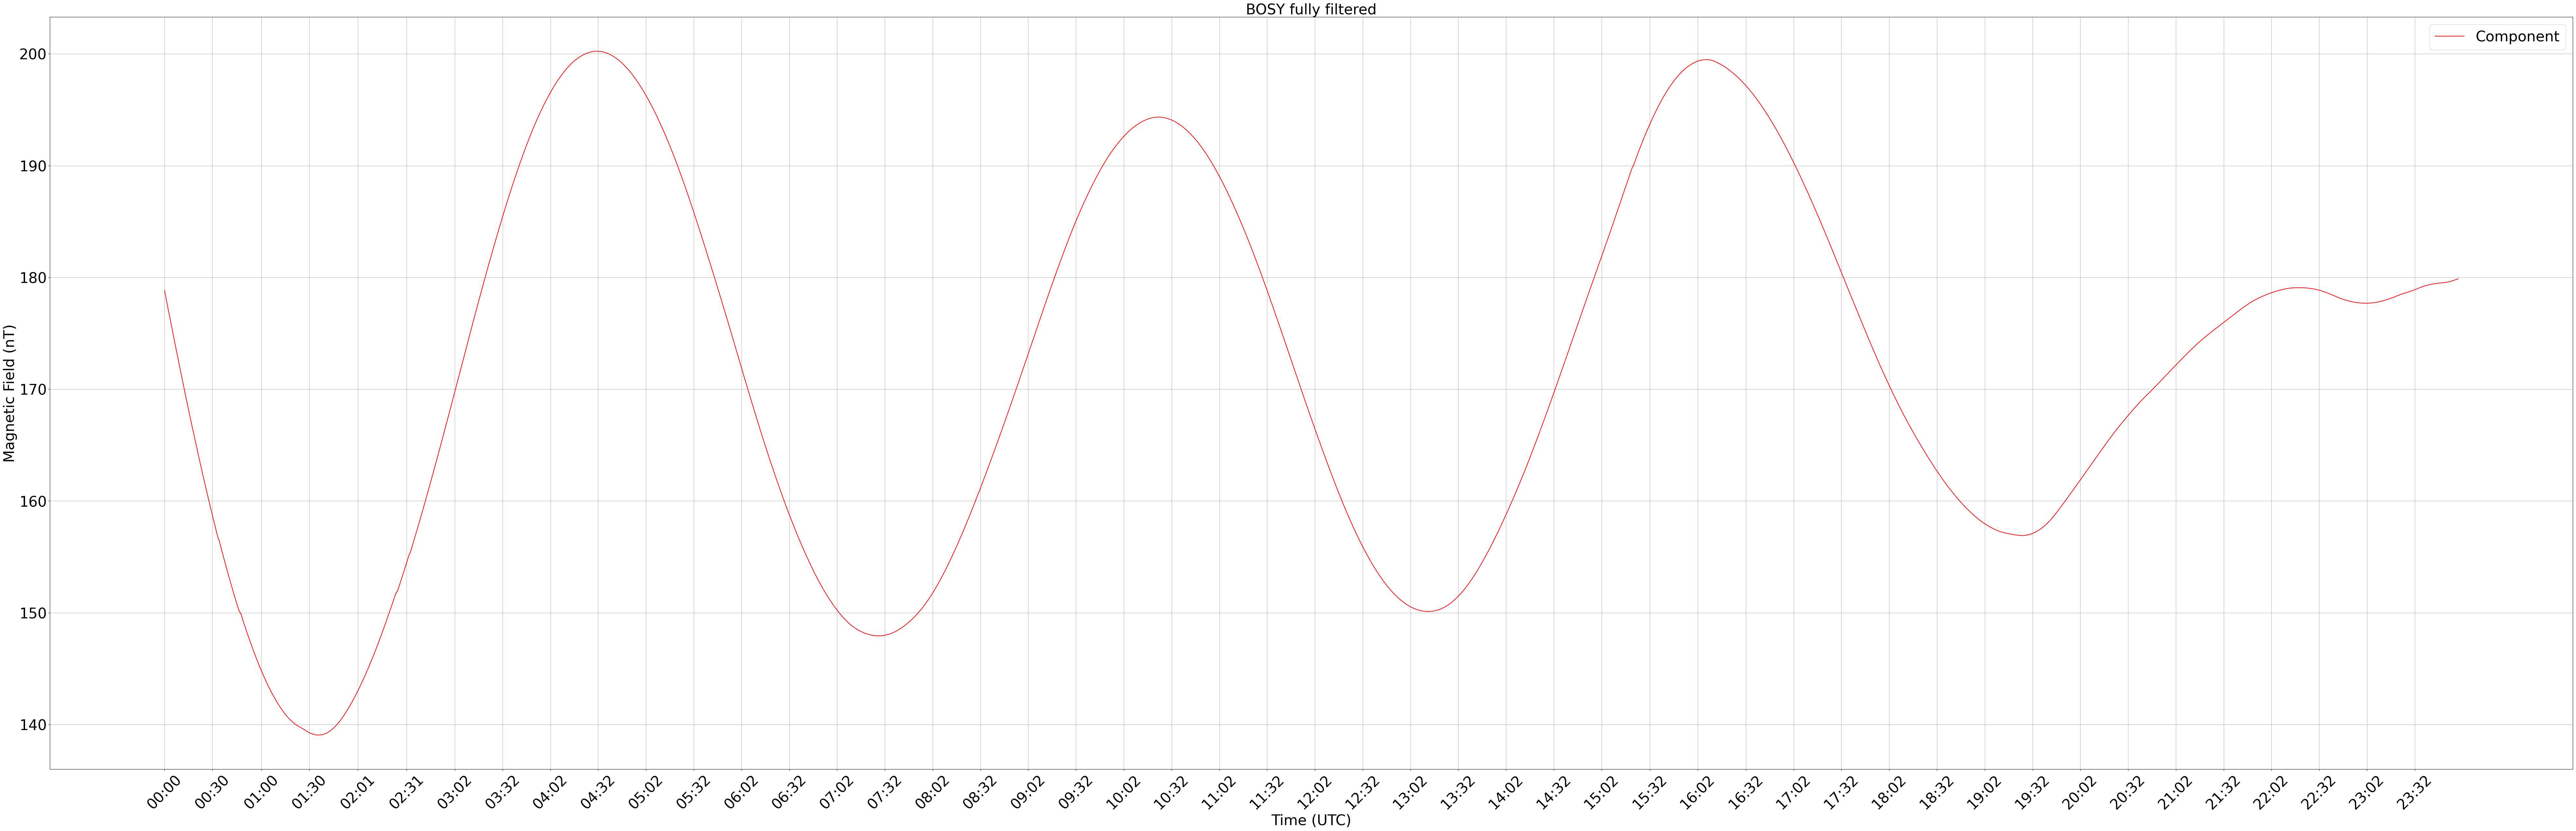

2025-06-18 01:40:35,810 - INFO - Plotting component and saving to ../data/assets/filtered/BOSZ_band_stop_filter.png


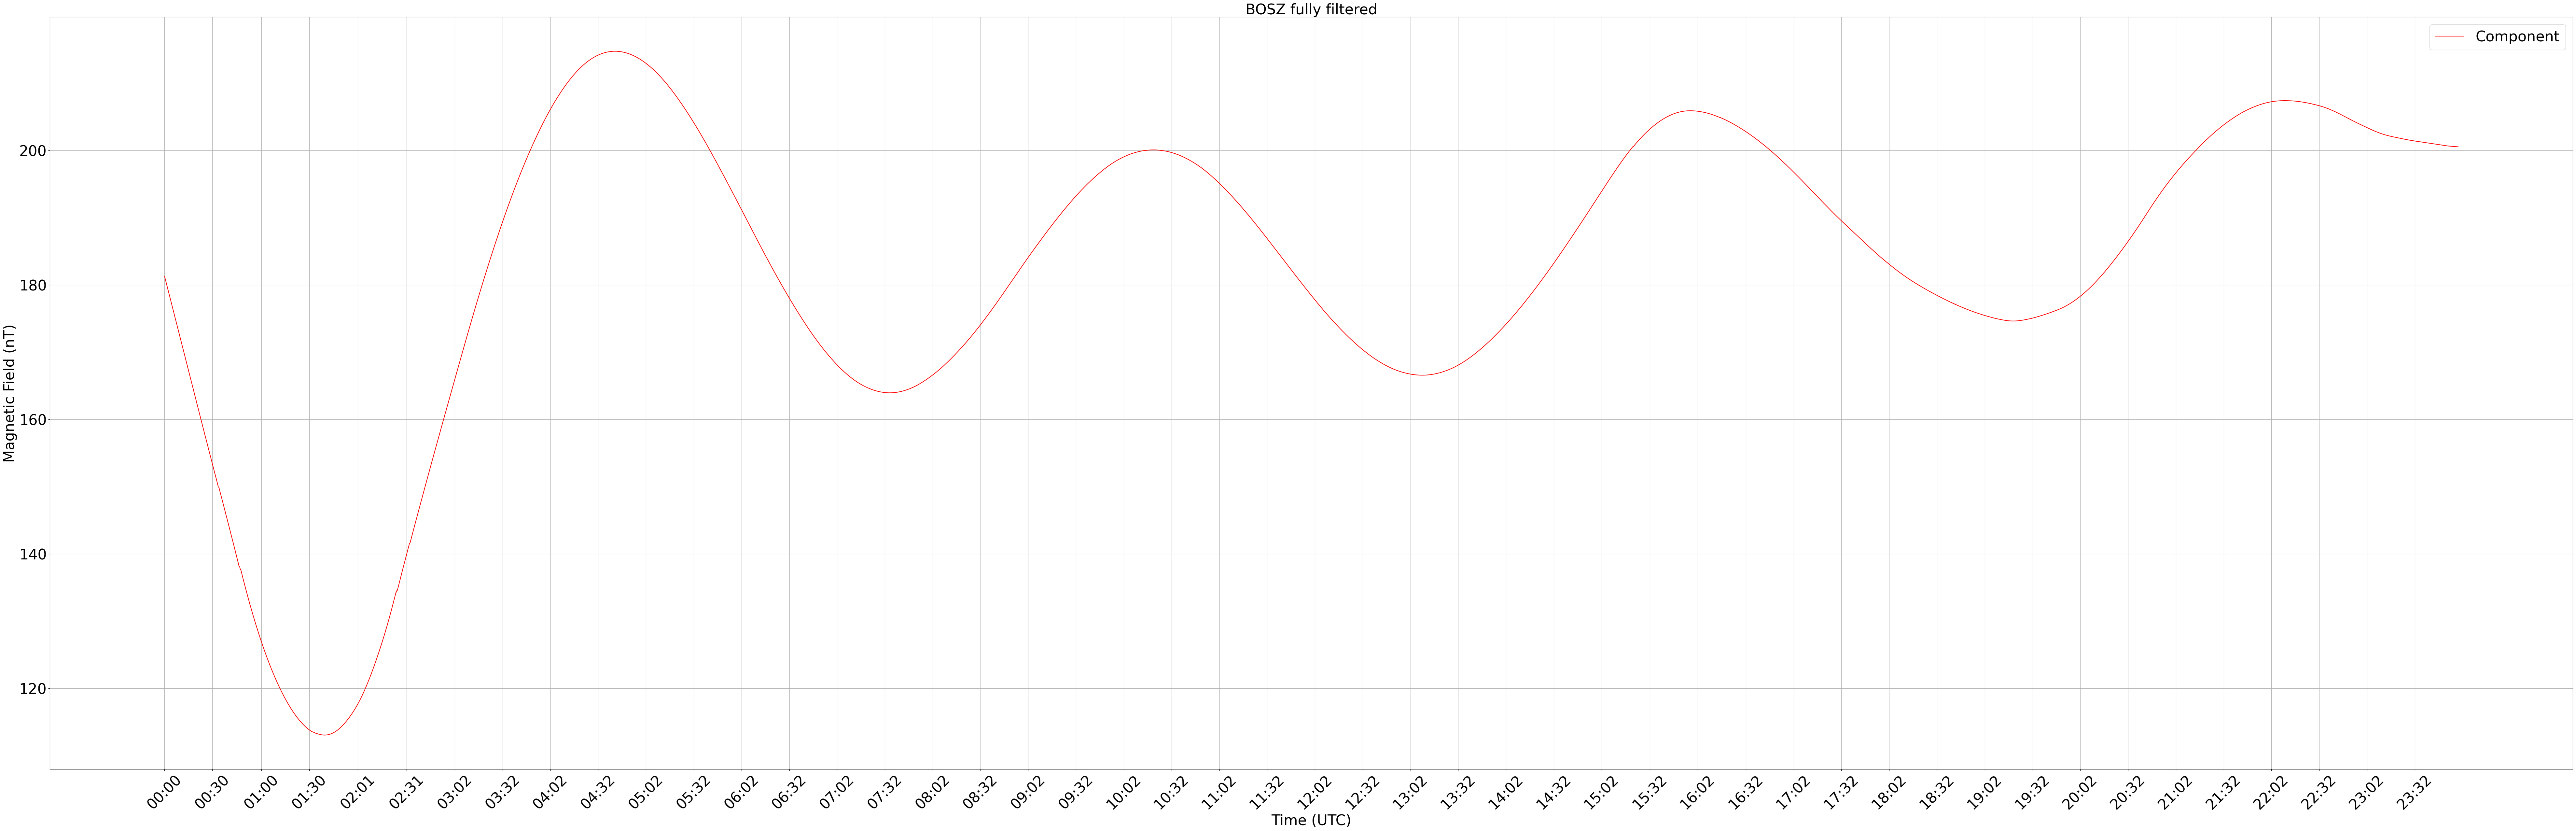

In [ ]:
# Applying band-stop filter NOT USED
LOW, MAX = (4e-5, 5e-5)
bsf_BOSX: np.ndarray = filtro_rechaza_banda(list(hff_BOSX), LOW, MAX, sampling_rate)
bsf_BOSY: np.ndarray = filtro_rechaza_banda(list(hff_BOSY), LOW, MAX, sampling_rate)
bsf_BOSZ: np.ndarray = filtro_rechaza_banda(list(hff_BOSZ), LOW, MAX, sampling_rate)
plot_component(TIME_UTC, list(bsf_BOSX), "BOSX fully filtered", '../data/assets/filtered/BOSX_band_stop_filter.png')
plot_component(TIME_UTC, list(bsf_BOSY), "BOSY fully filtered", '../data/assets/filtered/BOSY_band_stop_filter.png')
plot_component(TIME_UTC, list(bsf_BOSZ), "BOSZ fully filtered", '../data/assets/filtered/BOSZ_band_stop_filter.png')

In [48]:
# Total magnitude compute function
def compute_total_magnitude(x: list[float] | np.ndarray, y: list[float] | np.ndarray, z: list[float] | np.ndarray) -> np.ndarray:
    """
    Computes the total magnitude of a 3D vector signal.

    :param x: X component (list or np.ndarray)
    :param y: Y component (list or np.ndarray)
    :param z: Z component (list or np.ndarray)
    :return: Total magnitude as np.ndarray
    """
    x_arr = np.array(x)
    y_arr = np.array(y)
    z_arr = np.array(z)
    return np.sqrt(x_arr**2 + y_arr**2 + z_arr**2)

2025-06-18 01:50:43,222 - INFO - Plotting component and saving to ../data/assets/filtered/BOST_filtering_result.png


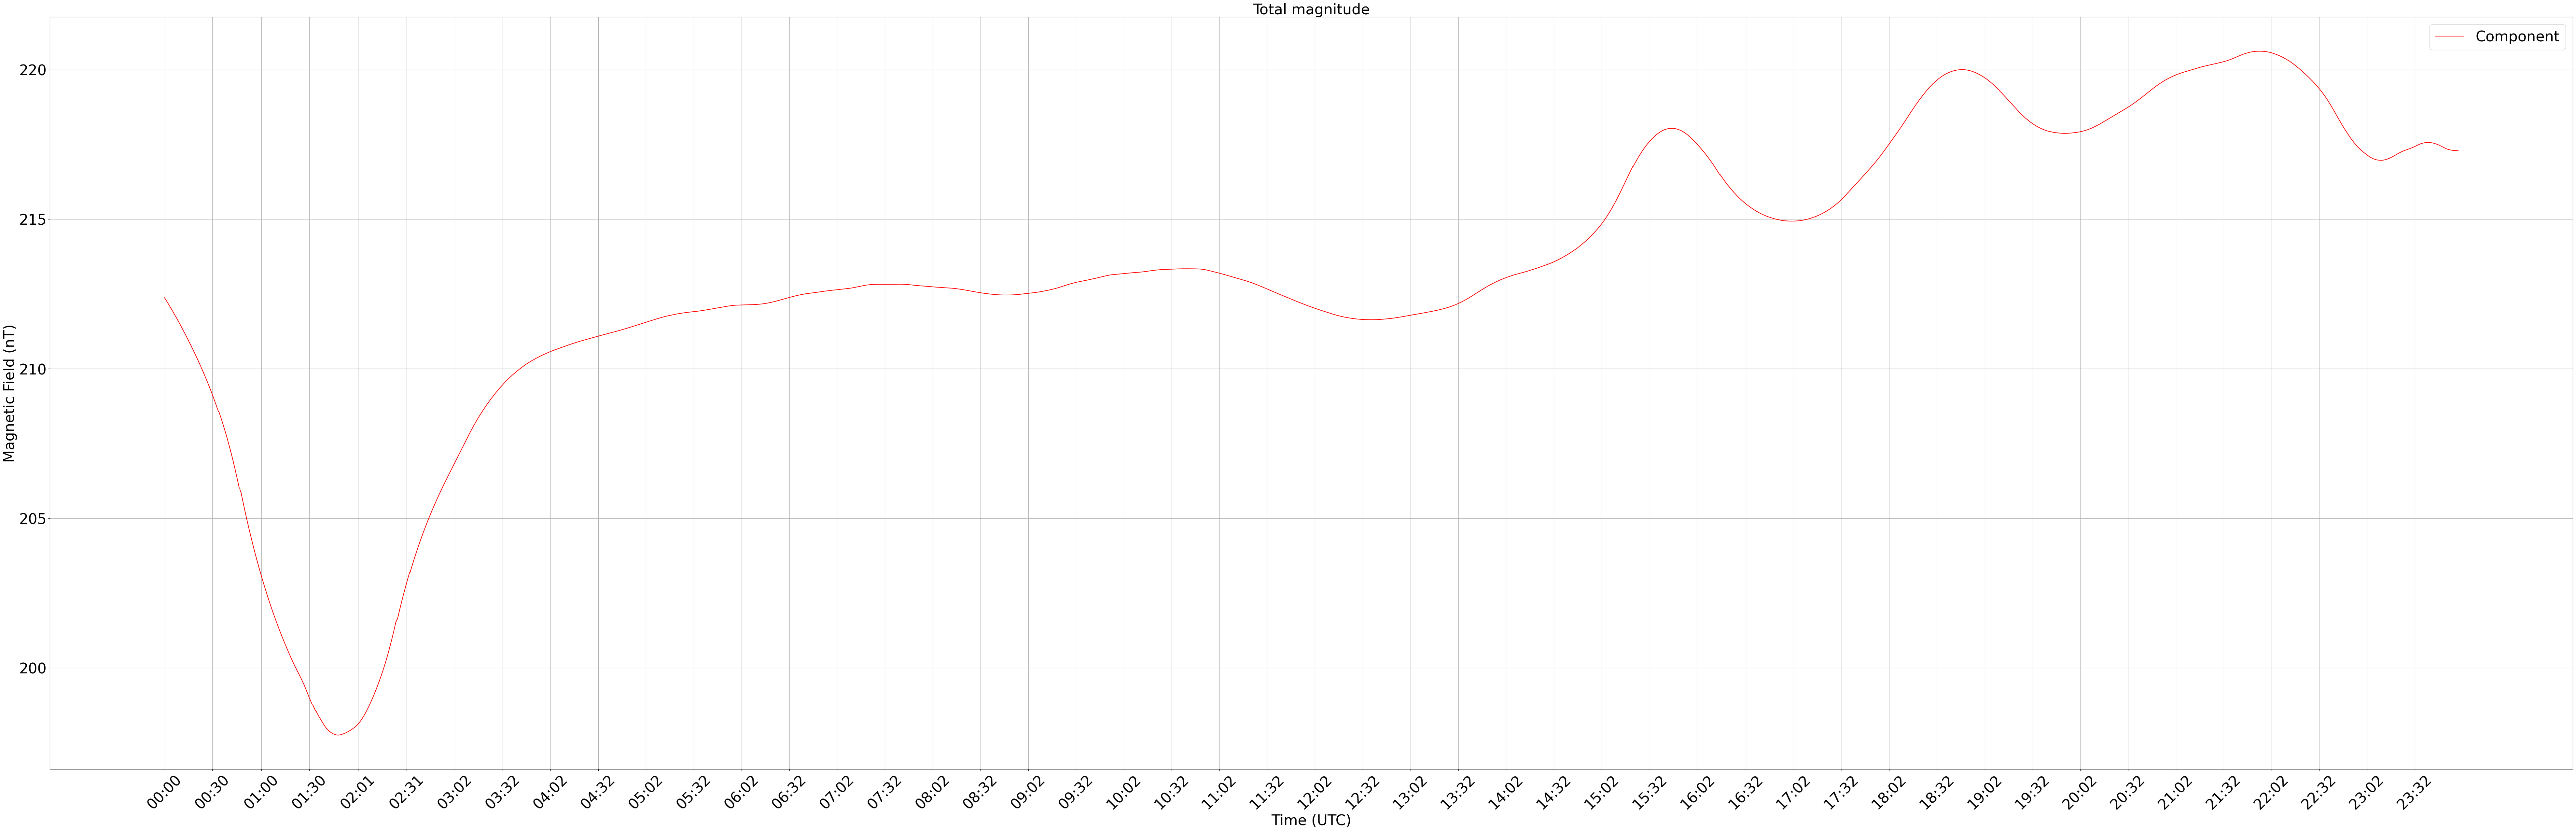

2025-06-18 01:50:44,991 - INFO - Plotting component and saving to ../data/assets/filtered/BOST_original.png


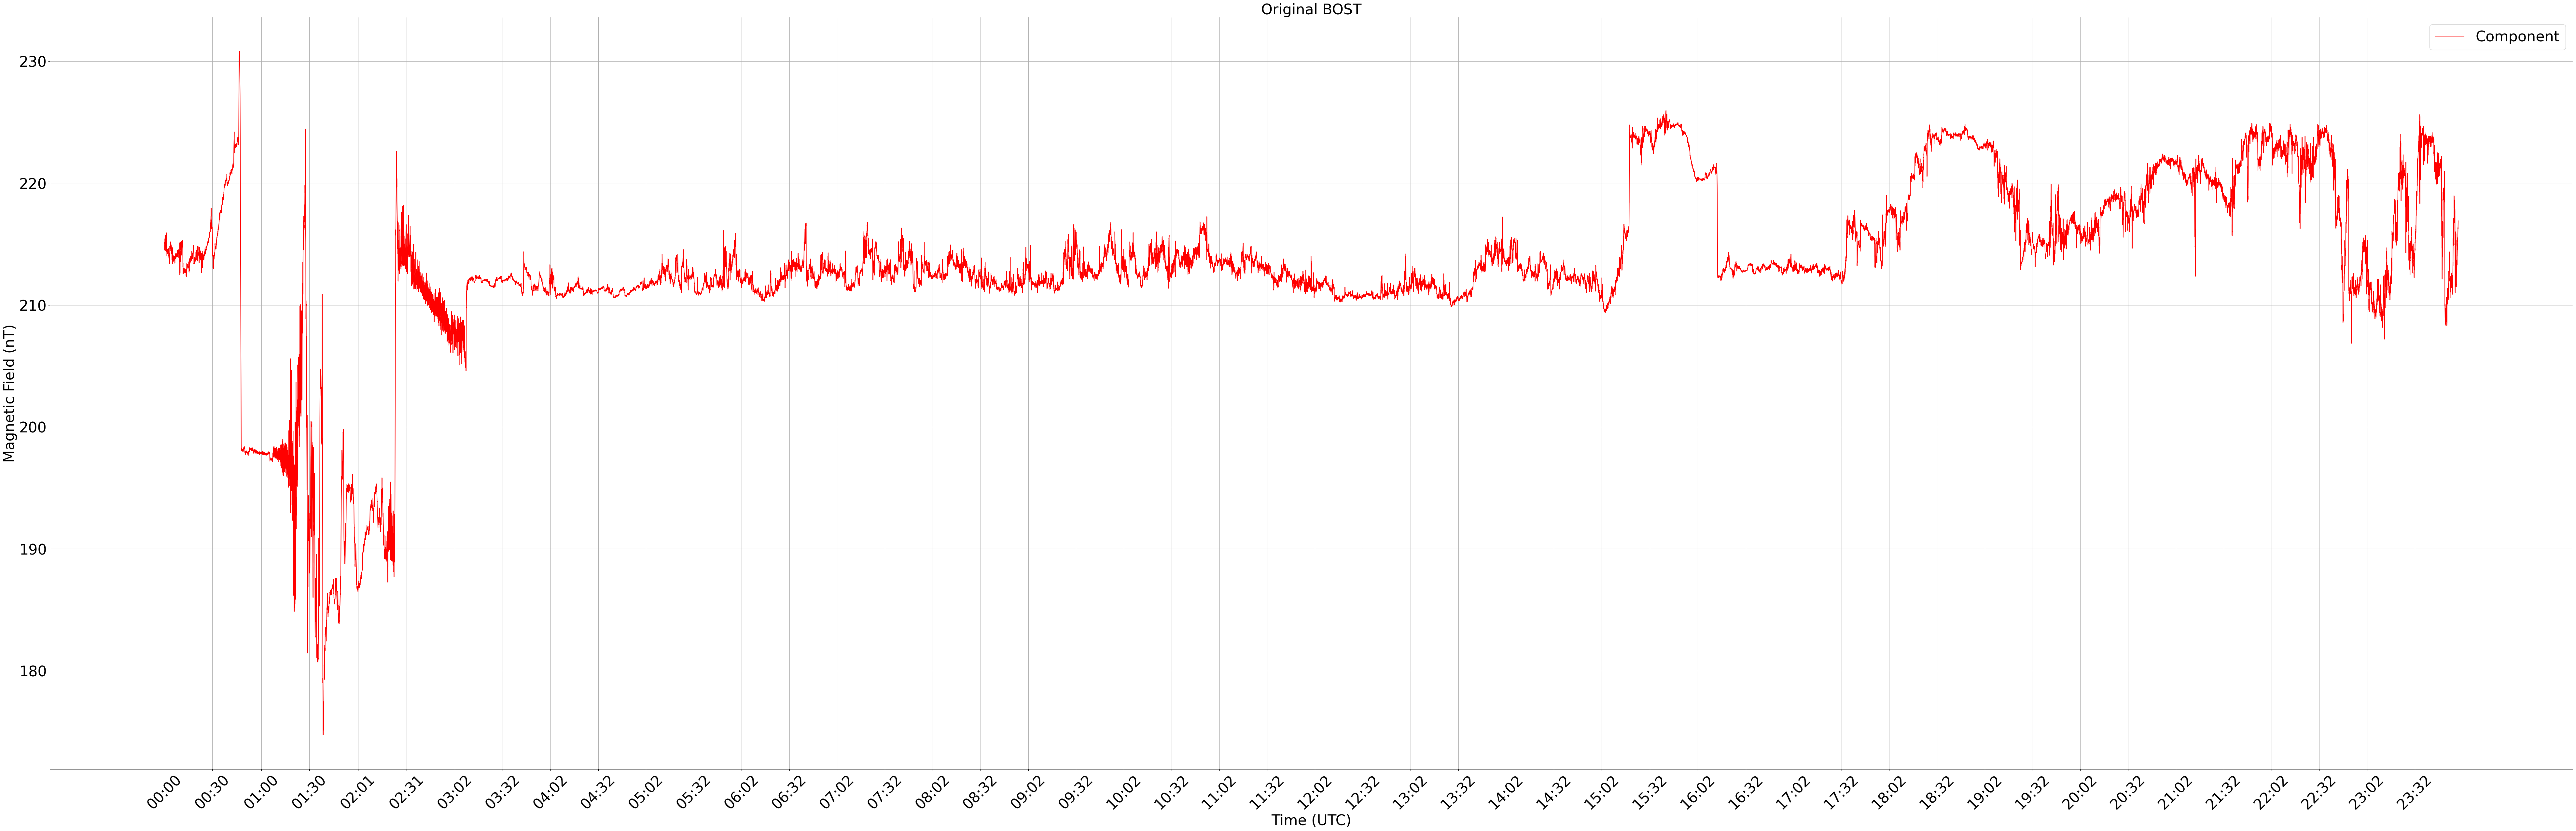

In [51]:
# Calculating BOST with results
hff_BOST: np.ndarray = compute_total_magnitude(hff_BOSX, hff_BOSY, hff_BOSZ)
#final_BOST: np.ndarray = compute_total_magnitude(bsf_BOSX, bsf_BOSY, bsf_BOSZ)
plot_component(TIME_UTC, list(hff_BOST), "Total magnitude", "../data/assets/filtered/BOST_filtering_result.png")
#plot_component(TIME_UTC, list(final_BOST), "Total magnitude", "../data/assets/filtered/BOST_filtering_result.png")
plot_component(TIME_UTC, BOST, "Original BOST", "../data/assets/filtered/BOST_original.png")

2025-06-18 02:00:23,514 - INFO - Plotting component and saving to ../data/assets/BOST_comparisson.png


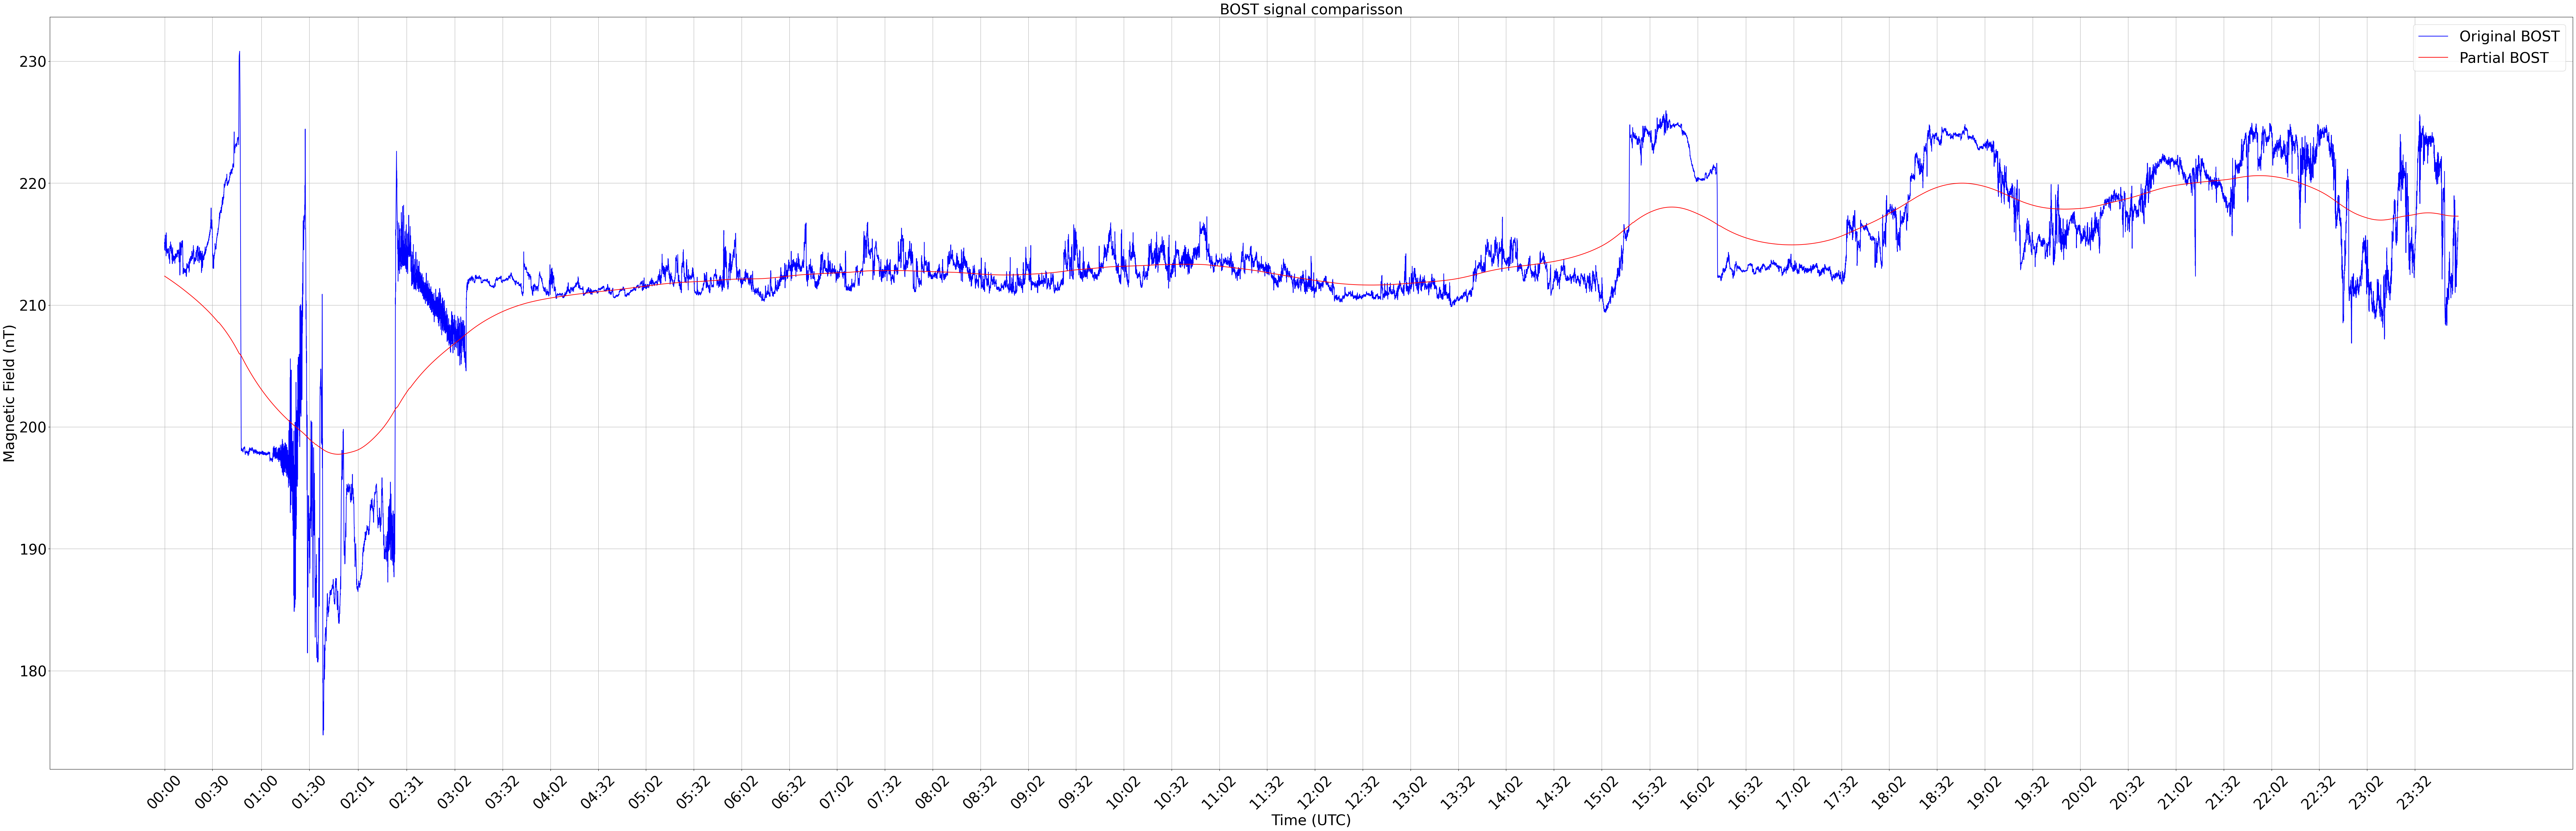

In [53]:
OUTPUT_FILE: str = "../data/assets/BOST_comparisson.png"
STEPS = 1800
logging.info(f"Plotting component and saving to {OUTPUT_FILE}")
plt.figure(figsize=(100, 30))
plt.plot(TIME_UTC, BOST, label='Original BOST', color='blue')  #type:ignore
plt.plot(TIME_UTC, hff_BOST, label='Partial BOST', color='red')  #type:ignore
#plt.plot(TIME_UTC, final_BOST, label='Resulting BOST', color='red')  #type:ignore

# plt.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.15)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=len(TIME_UTC)//3600 if len(TIME_UTC)//3600 > 0 else 1))
plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))
plt.legend(fontsize=32)
plt.grid(True)
plt.xticks(np.array(TIME_UTC)[::STEPS], rotation=45, fontsize=32)
plt.yticks(fontsize=32)
plt.xlabel('Time (UTC)', fontsize=32)
plt.ylabel('Magnetic Field (nT)', fontsize=32)
plt.title("BOST signal comparisson", fontsize=32)

plt.savefig(OUTPUT_FILE)
plt.show()
plt.close()